# Notebook 10 — TabPFN v3 re-run of Phase 1

- v2.6 (frozen): `results/phase1_tabpfn_3targets_3inputs_4strategies.csv`
- v3 (this notebook): `results/phase1_tabpfn_v3_3targets_3inputs_4strategies.csv`
- Shared engine: `src/tabpfn_evaluator.py` (now parametrized by `model_path`)

In [2]:
import os
os.environ["TABPFN_DISABLE_TELEMETRY"] = "1"

import sys, time
from pathlib import Path
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))

from src.cv_strategies import (
    random_kfold, temporal_holdout,
    temporal_blocked_kfold, leave_one_site_out,
)
from src.tabpfn_evaluator import run_tabpfn_with_splits, TABPFN_VERSION

In [3]:
import torch

print(f"TabPFN package version:  {TABPFN_VERSION}")
print(f"PyTorch CUDA available:   {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:                      {torch.cuda.get_device_name(0)}")
print()
print("NOTE: default model_path='auto' now resolves to the v3 checkpoint (tabpfn 8.x).")
print("      The v2.6 reproduction below uses the explicit cached v2.6 checkpoint.")

TabPFN package version:  8.0.6
PyTorch CUDA available:   True
GPU:                      NVIDIA L40S

NOTE: default model_path='auto' now resolves to the v3 checkpoint (tabpfn 8.x).
      The v2.6 reproduction below uses the explicit cached v2.6 checkpoint.


In [4]:
# Load all cleaned tables produced by Notebook 02 (with log1p applied)
PROCESSED_DIR = Path("../data/processed")

meta    = pd.read_csv(PROCESSED_DIR / "meta_clean.csv",    index_col=0)
otu_16s = pd.read_csv(PROCESSED_DIR / "otu_16s_clean.csv", index_col=0)
otu_18s = pd.read_csv(PROCESSED_DIR / "otu_18s_clean.csv", index_col=0)

# Build combined matrix (same as Notebooks 03, 05, 06, 07, 08)
otu_combined = pd.concat([otu_16s, otu_18s], axis=1)

# Sanity checks
assert (meta.index == otu_16s.index).all(), "meta vs 16S misaligned"
assert (meta.index == otu_18s.index).all(), "meta vs 18S misaligned"
assert otu_combined.columns.is_unique,       "duplicate columns in combined"
assert 'Chl_a_log1p' in meta.columns,        "Chl_a_log1p column missing"

print(f"meta:         {meta.shape}")
print(f"otu_16s:      {otu_16s.shape}")
print(f"otu_18s:      {otu_18s.shape}")
print(f"otu_combined: {otu_combined.shape}")
print("\n✓ All tables aligned.")

meta:         (1538, 24)
otu_16s:      (1538, 1236)
otu_18s:      (1538, 1054)
otu_combined: (1538, 2290)

✓ All tables aligned.


In [5]:
# ---- Experiment configuration (identical grid to Notebook 08) ----
RANDOM_SEED = 42

TARGETS = [
    {'name': 'temperature',   'col': 'temperature',  'log': False},
    {'name': 'salinity',      'col': 'salinity',     'log': False},
    {'name': 'Chl_a (log1p)', 'col': 'Chl_a_log1p',  'log': False},
]

INPUTS = {
    '16S':     otu_16s,
    '18S':     otu_18s,
    '16S+18S': otu_combined,
}

STRATEGIES = ['random_kfold', 'temporal_holdout', 'temporal_blocked_kfold', 'leave_one_site_out']

# ---- Model checkpoints (the ONLY thing that differs from Notebook 08) ----
# v2.6: explicit cached checkpoint — used only for the Section 0 guard.
# v3:   'auto' resolves to the v3 default under tabpfn 8.0.6 (pinned explicitly after first load).
V26_MODEL_PATH = "/mnt/data/home/tv2414/.cache/tabpfn/tabpfn-v2.6-regressor-v2.6_default.ckpt"
V3_MODEL_PATH  = "auto"

# ---- Same build_splits helper as Notebooks 06/07/08 ----
def build_splits(strategy_name, meta_valid, random_seed=42):
    n = len(meta_valid)
    if strategy_name == 'random_kfold':
        return random_kfold(n_samples=n, n_folds=5, random_seed=random_seed)
    elif strategy_name == 'temporal_holdout':
        return temporal_holdout(meta_valid, test_fraction=0.2)
    elif strategy_name == 'temporal_blocked_kfold':
        return temporal_blocked_kfold(meta_valid, n_folds=5)
    elif strategy_name == 'leave_one_site_out':
        return leave_one_site_out(meta_valid)
    raise ValueError(f"Unknown strategy: {strategy_name}")

all_rows = []

print(f"Random seed:    {RANDOM_SEED}")
print(f"Targets:        {[t['name'] for t in TARGETS]}")
print(f"Inputs:         {list(INPUTS.keys())}")
print(f"Strategies:     {STRATEGIES}")
print(f"Total v3 runs:  {len(TARGETS) * len(INPUTS) * len(STRATEGIES)}")
print(f"v2.6 ckpt:      {Path(V26_MODEL_PATH).name}")

Random seed:    42
Targets:        ['temperature', 'salinity', 'Chl_a (log1p)']
Inputs:         ['16S', '18S', '16S+18S']
Strategies:     ['random_kfold', 'temporal_holdout', 'temporal_blocked_kfold', 'leave_one_site_out']
Total v3 runs:  36
v2.6 ckpt:      tabpfn-v2.6-regressor-v2.6_default.ckpt


In [ ]:
# Section 0 — Reproducibility guard

# Frozen v2.6 target from results/phase1_tabpfn_3targets_3inputs_4strategies.csv (tabpfn 7.1.1)
V26_TARGET = {'r2': 0.5533, 'mae': 1.251, 'rmse': 1.521}

# --- Prepare the same cell as the original run ---
target_col = 'temperature'
valid_mask = meta[target_col].notna()
meta_v = meta.loc[valid_mask].reset_index(drop=True)
otu_v  = otu_16s.loc[valid_mask].reset_index(drop=True)

splits = build_splits('temporal_holdout', meta_v, RANDOM_SEED)

# --- Run with the EXPLICIT v2.6 checkpoint ---
print(f"Loading v2.6 checkpoint: {Path(V26_MODEL_PATH).name}\n")
t0 = time.time()
res_v26 = run_tabpfn_with_splits(
    target_name   = target_col,
    meta          = meta_v,
    otu           = otu_v,
    splits        = splits,
    strategy_name = 'temporal_holdout',
    input_name    = '16S',
    log_target    = False,
    random_seed   = RANDOM_SEED,
    model_path    = V26_MODEL_PATH,
    verbose       = True,
)
elapsed = time.time() - t0

# --- Compare reproduced vs frozen v2.6 ---
d_r2   = res_v26['r2_mean']   - V26_TARGET['r2']
d_mae  = res_v26['mae_mean']  - V26_TARGET['mae']
d_rmse = res_v26['rmse_mean'] - V26_TARGET['rmse']

TOL_R2, TOL_METRIC = 0.005, 0.02
passed = (abs(d_r2) < TOL_R2) and (abs(d_mae) < TOL_METRIC) and (abs(d_rmse) < TOL_METRIC)

print(f"\n{'=' * 60}")
print(f"  Reproducibility check · temperature × 16S × temporal_holdout")
print(f"{'=' * 60}")
print(f"  {'metric':<6}{'frozen v2.6':>14}{'reproduced':>14}{'Δ':>12}")
print(f"  {'R²':<6}{V26_TARGET['r2']:>14.4f}{res_v26['r2_mean']:>14.4f}{d_r2:>+12.4f}")
print(f"  {'MAE':<6}{V26_TARGET['mae']:>14.3f}{res_v26['mae_mean']:>14.3f}{d_mae:>+12.3f}")
print(f"  {'RMSE':<6}{V26_TARGET['rmse']:>14.3f}{res_v26['rmse_mean']:>14.3f}{d_rmse:>+12.3f}")
print(f"\n  model_path recorded: {res_v26['model_path']}")
print(f"  tabpfn package:      {res_v26['tabpfn_version']}")
print(f"  runtime:             {elapsed:.1f}s")
print(f"\n  VERDICT: " + (
    "✓ PASS — v2.6 reproduces; existing CSV is a valid baseline."
    if passed else
    "⚠ DIFFERS — check the Δ magnitude; if non-trivial we regenerate v2.6 under 8.0.6."
))

Loading v2.6 checkpoint: tabpfn-v2.6-regressor-v2.6_default.ckpt


  TabPFN · input=16S · target=temperature · strategy=temporal_holdout
  Samples: 1223    Features: 1236    Folds: 1
  No inner-CV (pretrained model)  ·  TabPFN v8.0.6
    Fold  1: R²=+0.5732  MAE=1.209  RMSE=1.487  time=7.6s

  Summary · temperature · 16S · temporal_holdout
    R²:    +0.5732  ±  0.0000
    MAE:   1.209  ±  0.000
    RMSE:  1.487  ±  0.000
    TabPFN version:          8.0.6
    Total CV time:           7.6s

  Reproducibility check · temperature × 16S × temporal_holdout
  metric   frozen v2.6    reproduced           Δ
  R²            0.5533        0.5732     +0.0199
  MAE            1.251         1.209      -0.042
  RMSE           1.521         1.487      -0.034

  model_path recorded: /mnt/data/home/tv2414/.cache/tabpfn/tabpfn-v2.6-regressor-v2.6_default.ckpt
  tabpfn package:      8.0.6
  runtime:             7.6s

  VERDICT: ⚠ DIFFERS — check the Δ magnitude; if non-trivial we regenerate v2.6 under 8

In [6]:
import os

token_path = os.path.expanduser("~/.tabpfn_token")
os.environ["TABPFN_TOKEN"] = open(token_path).read().strip()

print("TABPFN_TOKEN set:", bool(os.environ["TABPFN_TOKEN"]))

TABPFN_TOKEN set: True


In [ ]:
# Section 1 — v3 smoke test (same cell, model-only comparison)

print(f"v3 via model_path='{V3_MODEL_PATH}'  (first call downloads the v3 checkpoint)\n")
t0 = time.time()
res_v3_smoke = run_tabpfn_with_splits(
    target_name   = 'temperature',
    meta          = meta_v,
    otu           = otu_v,
    splits        = splits,
    strategy_name = 'temporal_holdout',
    input_name    = '16S',
    log_target    = False,
    random_seed   = RANDOM_SEED,
    model_path    = V3_MODEL_PATH,   # 'auto' -> v3 default under 8.0.6
    verbose       = True,
)
elapsed = time.time() - t0


print(f"\n{'=' * 56}")
print(f"  Same cell, same package (8.0.6) — model only")
print(f"  temperature × 16S × temporal_holdout")
print(f"{'=' * 56}")
print(f"  {'model':<14}{'R²':>10}{'MAE':>10}{'RMSE':>10}")
print(f"  {'v2.6 @8.0.6':<14}{res_v26['r2_mean']:>10.4f}{res_v26['mae_mean']:>10.3f}{res_v26['rmse_mean']:>10.3f}")
print(f"  {'v3   @8.0.6':<14}{res_v3_smoke['r2_mean']:>10.4f}{res_v3_smoke['mae_mean']:>10.3f}{res_v3_smoke['rmse_mean']:>10.3f}")
print(f"\n  v3 model_path: {res_v3_smoke['model_path']}")
print(f"  runtime:       {elapsed:.1f}s (incl. one-time download on first run)")

v3 via model_path='auto'  (first call downloads the v3 checkpoint)


  TabPFN · input=16S · target=temperature · strategy=temporal_holdout
  Samples: 1223    Features: 1236    Folds: 1
  No inner-CV (pretrained model)  ·  TabPFN v8.0.6
    Fold  1: R²=+0.6336  MAE=1.088  RMSE=1.378  time=4.1s

  Summary · temperature · 16S · temporal_holdout
    R²:    +0.6336  ±  0.0000
    MAE:   1.088  ±  0.000
    RMSE:  1.378  ±  0.000
    TabPFN version:          8.0.6
    Total CV time:           4.1s

  Same cell, same package (8.0.6) — model only
  temperature × 16S × temporal_holdout
  model                 R²       MAE      RMSE
  v2.6 @8.0.6       0.5732     1.209     1.487
  v3   @8.0.6       0.6336     1.088     1.378

  v3 model_path: auto
  runtime:       4.1s (incl. one-time download on first run)


In [ ]:

# Full 36-cell grid runner (define run_full_grid + save_partial)

CSV_COLS = [
    'target_display', 'target', 'input', 'strategy', 'log_target',
    'n_samples', 'n_features', 'n_folds',
    'r2_mean', 'r2_std', 'mae_mean', 'mae_std', 'rmse_mean', 'rmse_std',
    'total_time', 'notes', 'tabpfn_version', 'model_path',
]

def save_partial(rows, path):
    if not rows:
        return
    (pd.DataFrame(rows)[CSV_COLS]
       .round({'r2_mean': 4, 'r2_std': 4, 'mae_mean': 3, 'mae_std': 3,
               'rmse_mean': 3, 'rmse_std': 3, 'total_time': 1})
       .to_csv(path, index=False))

def run_full_grid(model_path, output_csv, model_tag):
    output_csv = Path(output_csv)
    rows = []
    n_total = len(TARGETS) * len(INPUTS) * len(STRATEGIES)
    cell = 0
    grid_t0 = time.time()

    print(f"{'#' * 70}")
    print(f"#  GRID RUN · {model_tag}")
    print(f"#  model_path: {model_path}")
    print(f"#  output:     {output_csv.name}")
    print(f"#  {n_total} cells (3 targets × 3 inputs × 4 strategies)")
    print(f"{'#' * 70}")

    for t in TARGETS:
        for input_name, otu_df in INPUTS.items():
            for strategy in STRATEGIES:
                cell += 1
                mask   = meta[t['col']].notna()
                meta_v = meta.loc[mask].reset_index(drop=True)
                otu_v  = otu_df.loc[mask].reset_index(drop=True)
                splits = build_splits(strategy, meta_v, RANDOM_SEED)

                print(f"\n[{cell}/{n_total}] {t['name']} × {input_name} × {strategy}  "
                      f"(samples={len(meta_v)}, features={otu_v.shape[1]}, folds={len(splits)})")
                res = run_tabpfn_with_splits(
                    target_name=t['col'], meta=meta_v, otu=otu_v, splits=splits,
                    strategy_name=strategy, input_name=input_name,
                    log_target=t['log'], random_seed=RANDOM_SEED,
                    model_path=model_path, verbose=False,
                )
                res['target_display'] = t['name']
                rows.append(res)
                save_partial(rows, output_csv)
                print(f"      R²={res['r2_mean']:+.4f}  MAE={res['mae_mean']:.3f}  "
                      f"RMSE={res['rmse_mean']:.3f}  ({res['total_time']:.1f}s)  → saved {len(rows)}/{n_total}")

    print(f"\n{'#' * 70}")
    print(f"#  DONE · {model_tag} · {len(rows)}/{n_total} cells · "
          f"{(time.time() - grid_t0)/60:.1f} min total · saved to {output_csv.name}")
    print(f"{'#' * 70}")
    return pd.DataFrame(rows)

print("✓ runner defined:", "run_full_grid" in globals(), "save_partial" in globals())

✓ runner defined: True True


In [10]:
# ============================================================
# Section 2a — Full grid: v2.6 @ 8.0.6 (regenerated baseline) · ~36 cells, ~1h
# ============================================================
V26_MODEL_PATH = "/mnt/data/home/tv2414/.cache/tabpfn/tabpfn-v2.6-regressor-v2.6_default.ckpt"
df_v26 = run_full_grid(
    V26_MODEL_PATH,
    "../results/phase1_tabpfn_v26_3targets_3inputs_4strategies.csv",
    "v2.6 @8.0.6",
)

######################################################################
#  GRID RUN · v2.6 @8.0.6
#  model_path: /mnt/data/home/tv2414/.cache/tabpfn/tabpfn-v2.6-regressor-v2.6_default.ckpt
#  output:     phase1_tabpfn_v26_3targets_3inputs_4strategies.csv
#  36 cells (3 targets × 3 inputs × 4 strategies)
######################################################################

[1/36] temperature × 16S × random_kfold  (samples=1223, features=1236, folds=5)
      R²=+0.9833  MAE=0.615  RMSE=0.812  (29.8s)  → saved 1/36

[2/36] temperature × 16S × temporal_holdout  (samples=1223, features=1236, folds=1)
      R²=+0.5732  MAE=1.209  RMSE=1.487  (6.1s)  → saved 2/36

[3/36] temperature × 16S × temporal_blocked_kfold  (samples=1223, features=1236, folds=5)
      R²=+0.4545  MAE=1.413  RMSE=1.811  (28.9s)  → saved 3/36

[4/36] temperature × 16S × leave_one_site_out  (samples=1223, features=1236, folds=14)
      R²=+0.9477  MAE=0.823  RMSE=1.078  (85.9s)  → saved 4/36

[5/36] temperature × 18S × r

In [11]:
# ============================================================
# Section 2b — Full grid: v3 @ 8.0.6 (the new model) · ~36 cells, ~1h
# ============================================================
V3_MODEL_PATH = "/mnt/data/home/tv2414/.cache/tabpfn/tabpfn-v3-regressor-v3_default.ckpt"
df_v3 = run_full_grid(
    V3_MODEL_PATH,
    "../results/phase1_tabpfn_v3_3targets_3inputs_4strategies.csv",
    "v3 @8.0.6",
)

######################################################################
#  GRID RUN · v3 @8.0.6
#  model_path: /mnt/data/home/tv2414/.cache/tabpfn/tabpfn-v3-regressor-v3_default.ckpt
#  output:     phase1_tabpfn_v3_3targets_3inputs_4strategies.csv
#  36 cells (3 targets × 3 inputs × 4 strategies)
######################################################################

[1/36] temperature × 16S × random_kfold  (samples=1223, features=1236, folds=5)
      R²=+0.9852  MAE=0.565  RMSE=0.763  (12.3s)  → saved 1/36

[2/36] temperature × 16S × temporal_holdout  (samples=1223, features=1236, folds=1)
      R²=+0.6336  MAE=1.088  RMSE=1.378  (2.8s)  → saved 2/36

[3/36] temperature × 16S × temporal_blocked_kfold  (samples=1223, features=1236, folds=5)
      R²=+0.5054  MAE=1.319  RMSE=1.709  (11.9s)  → saved 3/36

[4/36] temperature × 16S × leave_one_site_out  (samples=1223, features=1236, folds=14)
      R²=+0.9552  MAE=0.755  RMSE=1.006  (34.2s)  → saved 4/36

[5/36] temperature × 18S × random_k

In [ ]:
# Section 3 — Load all Phase 1 result CSVs for the v3 comparison.

import glob

RESULTS_DIR = Path("../results")
csv_paths = sorted(glob.glob(str(RESULTS_DIR / "phase1_*.csv")))

loaded = {}
print("Found phase1 CSVs:\n")
for p in csv_paths:
    name = Path(p).name
    df = pd.read_csv(p)
    loaded[name] = df

    extra = ""
    if "tabpfn_version" in df.columns:
        extra += f" | tabpfn={df['tabpfn_version'].unique().tolist()}"
    if "model_path" in df.columns:
        mp = [(Path(str(x)).name if str(x) != 'auto' else 'auto') for x in df['model_path'].unique()]
        extra += f" | ckpt={mp}"
    strategies = sorted(df['strategy'].unique()) if 'strategy' in df.columns else '?'

    print(f"  {name}")
    print(f"     rows={len(df)}  strategies={strategies}{extra}")
    print(f"     columns={list(df.columns)}\n")

Found phase1 CSVs:

  phase1_baselines_3targets_16s.csv
     rows=7  strategies=?
     columns=['model', 'target', 'transform', 'n_samples', 'r2_mean', 'r2_std', 'mae_mean', 'mae_std', 'rmse_mean', 'rmse_std']

  phase1_comparison_lasso_vs_xgboost.csv
     rows=54  strategies=['leave_one_site_out', 'temporal_blocked_kfold', 'temporal_holdout']
     columns=['strategy', 'input', 'target', 'n_folds', 'n_samples', 'n_features', 'r2_mean', 'r2_std', 'mae_mean', 'mae_std', 'rmse_mean', 'rmse_std', 'alpha_mean', 'n_selected_mean', 'total_time', 'model', 'target_display', 'log_target', 'best_max_depth_mode', 'best_lr_mode', 'best_n_est_mode']

  phase1_four_model_comparison.csv
     rows=36  strategies=['leave_one_site_out', 'random_kfold', 'temporal_blocked_kfold', 'temporal_holdout']
     columns=['target_display', 'input', 'strategy', 'Lasso', 'RF', 'XGBoost', 'TabPFN', 'best_model', 'best_r2']

  phase1_lasso_3newstrategies.csv
     rows=27  strategies=['leave_one_site_out', 'temporal_blo

In [ ]:
# Section 4 — v3 vs baselines: win/loss grid + the 4 Chl_a exceptions

KEYS = ['target', 'input', 'strategy']
files = {
    'Lasso':   'phase1_lasso_3targets_3inputs_4strategies.csv',
    'RF':      'phase1_random_forest_3targets_3inputs_4strategies.csv',
    'XGBoost': 'phase1_xgboost_3targets_3inputs_4strategies.csv',
    'v2.6':    'phase1_tabpfn_v26_3targets_3inputs_4strategies.csv',
    'v3':      'phase1_tabpfn_v3_3targets_3inputs_4strategies.csv',
}

# Sanity: confirm key values align across files (avoids a broken merge)
print("Key alignment:")
for label, fname in files.items():
    d = loaded[fname]
    print(f"  {label:8s} targets={sorted(d['target'].unique())}  inputs={sorted(d['input'].unique())}")
print()

# Wide table: one R² column per model
merged = None
for label, fname in files.items():
    d = loaded[fname][KEYS + ['r2_mean']].rename(columns={'r2_mean': label})
    merged = d if merged is None else merged.merge(d, on=KEYS, how='outer')

n_nan = merged[list(files)].isna().any(axis=1).sum()
print(f"Merged cells: {len(merged)} (should be 36) · rows with missing values: {n_nan}")
print()

baselines = ['Lasso', 'RF', 'XGBoost']
merged['best_base']      = merged[baselines].max(axis=1)
merged['best_base_name'] = merged[baselines].idxmax(axis=1)
merged['v2.6_wins'] = merged['v2.6'] > merged['best_base']
merged['v3_wins']   = merged['v3']   > merged['best_base']

N = len(merged)
print(f"TabPFN v2.6 @8.0.6 beats all 3 baselines: {merged['v2.6_wins'].sum()}/{N}")
print(f"TabPFN v3   @8.0.6 beats all 3 baselines: {merged['v3_wins'].sum()}/{N}")

newly_won  = merged[merged['v3_wins'] & ~merged['v2.6_wins']]
newly_lost = merged[~merged['v3_wins'] &  merged['v2.6_wins']]
print(f"\nFlipped to WIN by v3 ({len(newly_won)}):")
for _, r in newly_won.iterrows():
    print(f"   {r['target']:12s} {r['input']:8s} {r['strategy']:22s}  v3={r['v3']:+.3f}  best base {r['best_base_name']}={r['best_base']:+.3f}")
print(f"Flipped to LOSS by v3 ({len(newly_lost)}):")
for _, r in newly_lost.iterrows():
    print(f"   {r['target']:12s} {r['input']:8s} {r['strategy']:22s}  v3={r['v3']:+.3f}  best base {r['best_base_name']}={r['best_base']:+.3f}")

# The original 4 exceptions: Chl_a × eukaryotic × temporal
print("\n" + "=" * 82)
print("  Original 4 exceptions: Chl_a × (18S, 16S+18S) × temporal")
print("=" * 82)
exc = merged[(merged['target'] == 'Chl_a_log1p') &
             (merged['input'].isin(['18S', '16S+18S'])) &
             (merged['strategy'].isin(['temporal_holdout', 'temporal_blocked_kfold']))]
print(exc[['input', 'strategy', 'Lasso', 'RF', 'XGBoost', 'v2.6', 'v3', 'v3_wins']].to_string(index=False))

Key alignment:
  Lasso    targets=['Chl_a (log1p)', 'salinity', 'temperature']  inputs=['16S', '16S+18S', '18S']
  RF       targets=['Chl_a_log1p', 'salinity', 'temperature']  inputs=['16S', '16S+18S', '18S']
  XGBoost  targets=['Chl_a_log1p', 'salinity', 'temperature']  inputs=['16S', '16S+18S', '18S']
  v2.6     targets=['Chl_a_log1p', 'salinity', 'temperature']  inputs=['16S', '16S+18S', '18S']
  v3       targets=['Chl_a_log1p', 'salinity', 'temperature']  inputs=['16S', '16S+18S', '18S']

Merged cells: 48 (should be 36) · rows with missing values: 24

TabPFN v2.6 @8.0.6 beats all 3 baselines: 33/48
TabPFN v3   @8.0.6 beats all 3 baselines: 34/48

Flipped to WIN by v3 (3):
   Chl_a_log1p  16S      temporal_holdout        v3=+0.821  best base RF=+0.784
   Chl_a_log1p  16S+18S  temporal_holdout        v3=+0.848  best base RF=+0.816
   Chl_a_log1p  18S      temporal_holdout        v3=+0.841  best base XGBoost=+0.813
Flipped to LOSS by v3 (2):
   Chl_a_log1p  16S+18S  temporal_blocked_k

In [14]:
# Fix: Lasso labels chlorophyll 'Chl_a (log1p)'; others use 'Chl_a_log1p'. Normalize, then merge.
TARGET_NORM = {'Chl_a (log1p)': 'Chl_a_log1p'}

merged = None
for label, fname in files.items():
    d = loaded[fname][KEYS + ['r2_mean']].copy()
    d['target'] = d['target'].replace(TARGET_NORM)
    d = d.rename(columns={'r2_mean': label})
    merged = d if merged is None else merged.merge(d, on=KEYS, how='outer')

print(f"Merged cells: {len(merged)} (should be 36) · missing: {merged[list(files)].isna().any(axis=1).sum()}")

baselines = ['Lasso', 'RF', 'XGBoost']
merged['best_base']      = merged[baselines].max(axis=1)
merged['best_base_name'] = merged[baselines].idxmax(axis=1)
merged['v2.6_wins'] = merged['v2.6'] > merged['best_base']
merged['v3_wins']   = merged['v3']   > merged['best_base']

N = len(merged)
print(f"v2.6 @8.0.6 beats all baselines: {merged['v2.6_wins'].sum()}/{N}")
print(f"v3   @8.0.6 beats all baselines: {merged['v3_wins'].sum()}/{N}")

for which, mask in [('WIN',  merged['v3_wins'] & ~merged['v2.6_wins']),
                    ('LOSS', ~merged['v3_wins'] &  merged['v2.6_wins'])]:
    sub = merged[mask]
    print(f"\nFlipped to {which} by v3 ({len(sub)}):")
    for _, r in sub.iterrows():
        print(f"   {r['target']:12s} {r['input']:8s} {r['strategy']:22s}  "
              f"v3={r['v3']:+.3f}  v2.6={r['v2.6']:+.3f}  best base {r['best_base_name']}={r['best_base']:+.3f}")

exc = merged[(merged['target'] == 'Chl_a_log1p') &
             (merged['input'].isin(['18S', '16S+18S'])) &
             (merged['strategy'].isin(['temporal_holdout', 'temporal_blocked_kfold']))]
print("\nOriginal 4 exceptions (Chl_a × eukaryotic × temporal):")
print(exc[['input', 'strategy', 'Lasso', 'RF', 'XGBoost', 'v2.6', 'v3', 'v3_wins']].to_string(index=False))

Merged cells: 36 (should be 36) · missing: 0
v2.6 @8.0.6 beats all baselines: 33/36
v3   @8.0.6 beats all baselines: 34/36

Flipped to WIN by v3 (3):
   Chl_a_log1p  16S      temporal_holdout        v3=+0.821  v2.6=+0.781  best base RF=+0.784
   Chl_a_log1p  16S+18S  temporal_holdout        v3=+0.848  v2.6=+0.813  best base RF=+0.816
   Chl_a_log1p  18S      temporal_holdout        v3=+0.841  v2.6=+0.761  best base XGBoost=+0.813

Flipped to LOSS by v3 (2):
   Chl_a_log1p  16S+18S  temporal_blocked_kfold  v3=+0.662  v2.6=+0.679  best base XGBoost=+0.664
   salinity     16S      temporal_holdout        v3=+0.925  v2.6=+0.931  best base XGBoost=+0.925

Original 4 exceptions (Chl_a × eukaryotic × temporal):
  input               strategy    Lasso     RF  XGBoost   v2.6     v3  v3_wins
16S+18S temporal_blocked_kfold  -6.7183 0.6460   0.6642 0.6787 0.6625    False
16S+18S       temporal_holdout  -0.1812 0.8156   0.8117 0.8128 0.8484     True
    18S temporal_blocked_kfold -55.5269 0.6240   

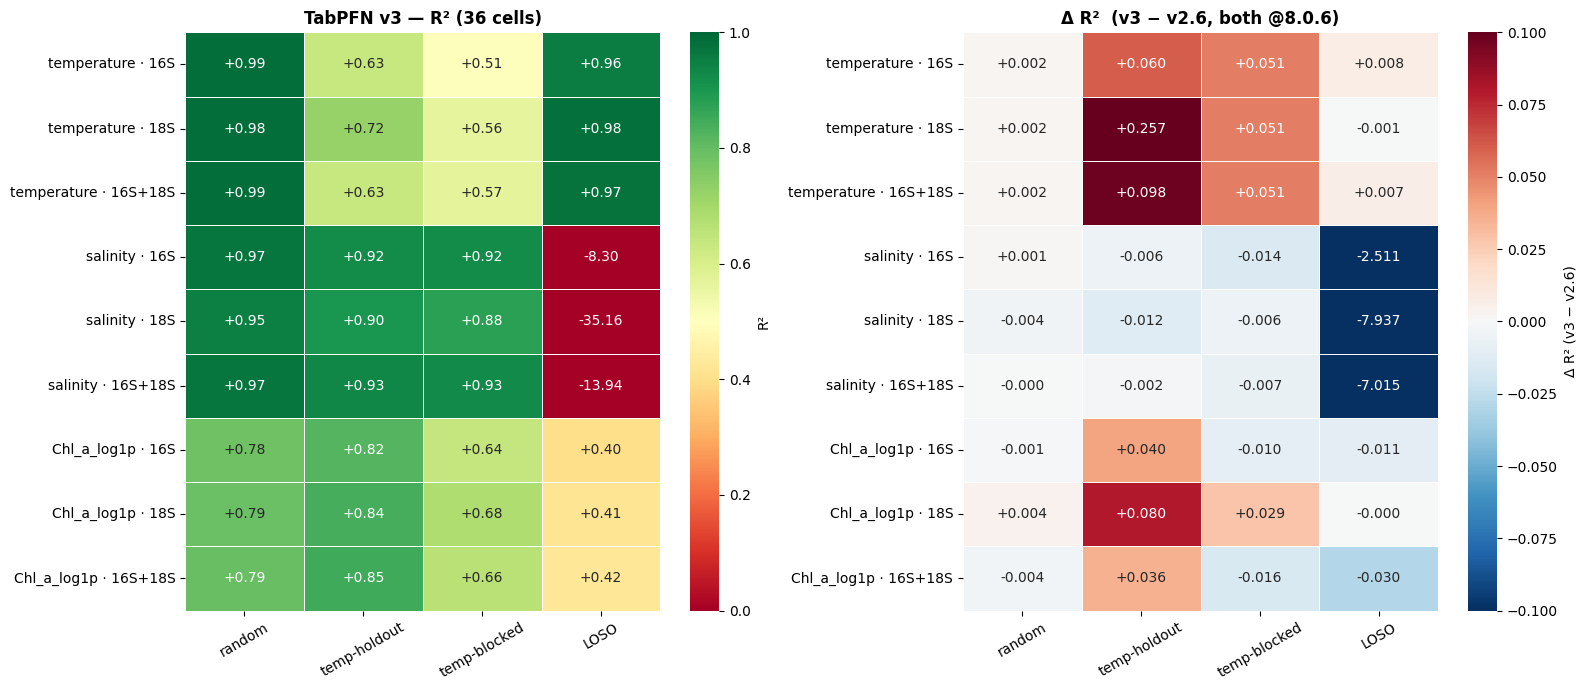

saved → ../results/phase1_tabpfn_v3_vs_v26_heatmaps.png
saved → ../results/phase1_tabpfn_v3_vs_v26_heatmaps.pdf


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RESULTS_DIR = Path("../results")

target_order   = ['temperature', 'salinity', 'Chl_a_log1p']
input_order    = ['16S', '18S', '16S+18S']
strategy_order = ['random_kfold', 'temporal_holdout', 'temporal_blocked_kfold', 'leave_one_site_out']
strategy_short = {'random_kfold': 'random', 'temporal_holdout': 'temp-holdout',
                  'temporal_blocked_kfold': 'temp-blocked', 'leave_one_site_out': 'LOSO'}

m = merged.copy()
m['target']   = pd.Categorical(m['target'], target_order, ordered=True)
m['input']    = pd.Categorical(m['input'], input_order, ordered=True)
m['strategy'] = pd.Categorical(m['strategy'], strategy_order, ordered=True)
m['row'] = m['target'].astype(str) + ' · ' + m['input'].astype(str)
row_order = [f"{t} · {i}" for t in target_order for i in input_order]

def pivot(col):
    p = m.pivot_table(index='row', columns='strategy', values=col, observed=True)
    return p.reindex(index=row_order, columns=strategy_order).rename(columns=strategy_short)

r2_v3 = pivot('v3')
delta = pivot('v3') - pivot('v2.6')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(r2_v3, annot=True, fmt='+.2f', cmap='RdYlGn', vmin=0.0, vmax=1.0,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'R²'}, ax=axes[0])
axes[0].set_title('TabPFN v3 — R² (36 cells)', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('')

sns.heatmap(delta, annot=True, fmt='+.3f', cmap='RdBu_r', center=0, vmin=-0.1, vmax=0.1,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Δ R² (v3 − v2.6)'}, ax=axes[1])
axes[1].set_title('Δ R²  (v3 − v2.6, both @8.0.6)', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('')

for ax in axes:
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)
plt.tight_layout()

png = RESULTS_DIR / 'phase1_tabpfn_v3_vs_v26_heatmaps.png'
pdf = RESULTS_DIR / 'phase1_tabpfn_v3_vs_v26_heatmaps.pdf'
fig.savefig(png, dpi=300, bbox_inches='tight')
fig.savefig(pdf, bbox_inches='tight')
plt.show()
print(f"saved → {png}\nsaved → {pdf}")

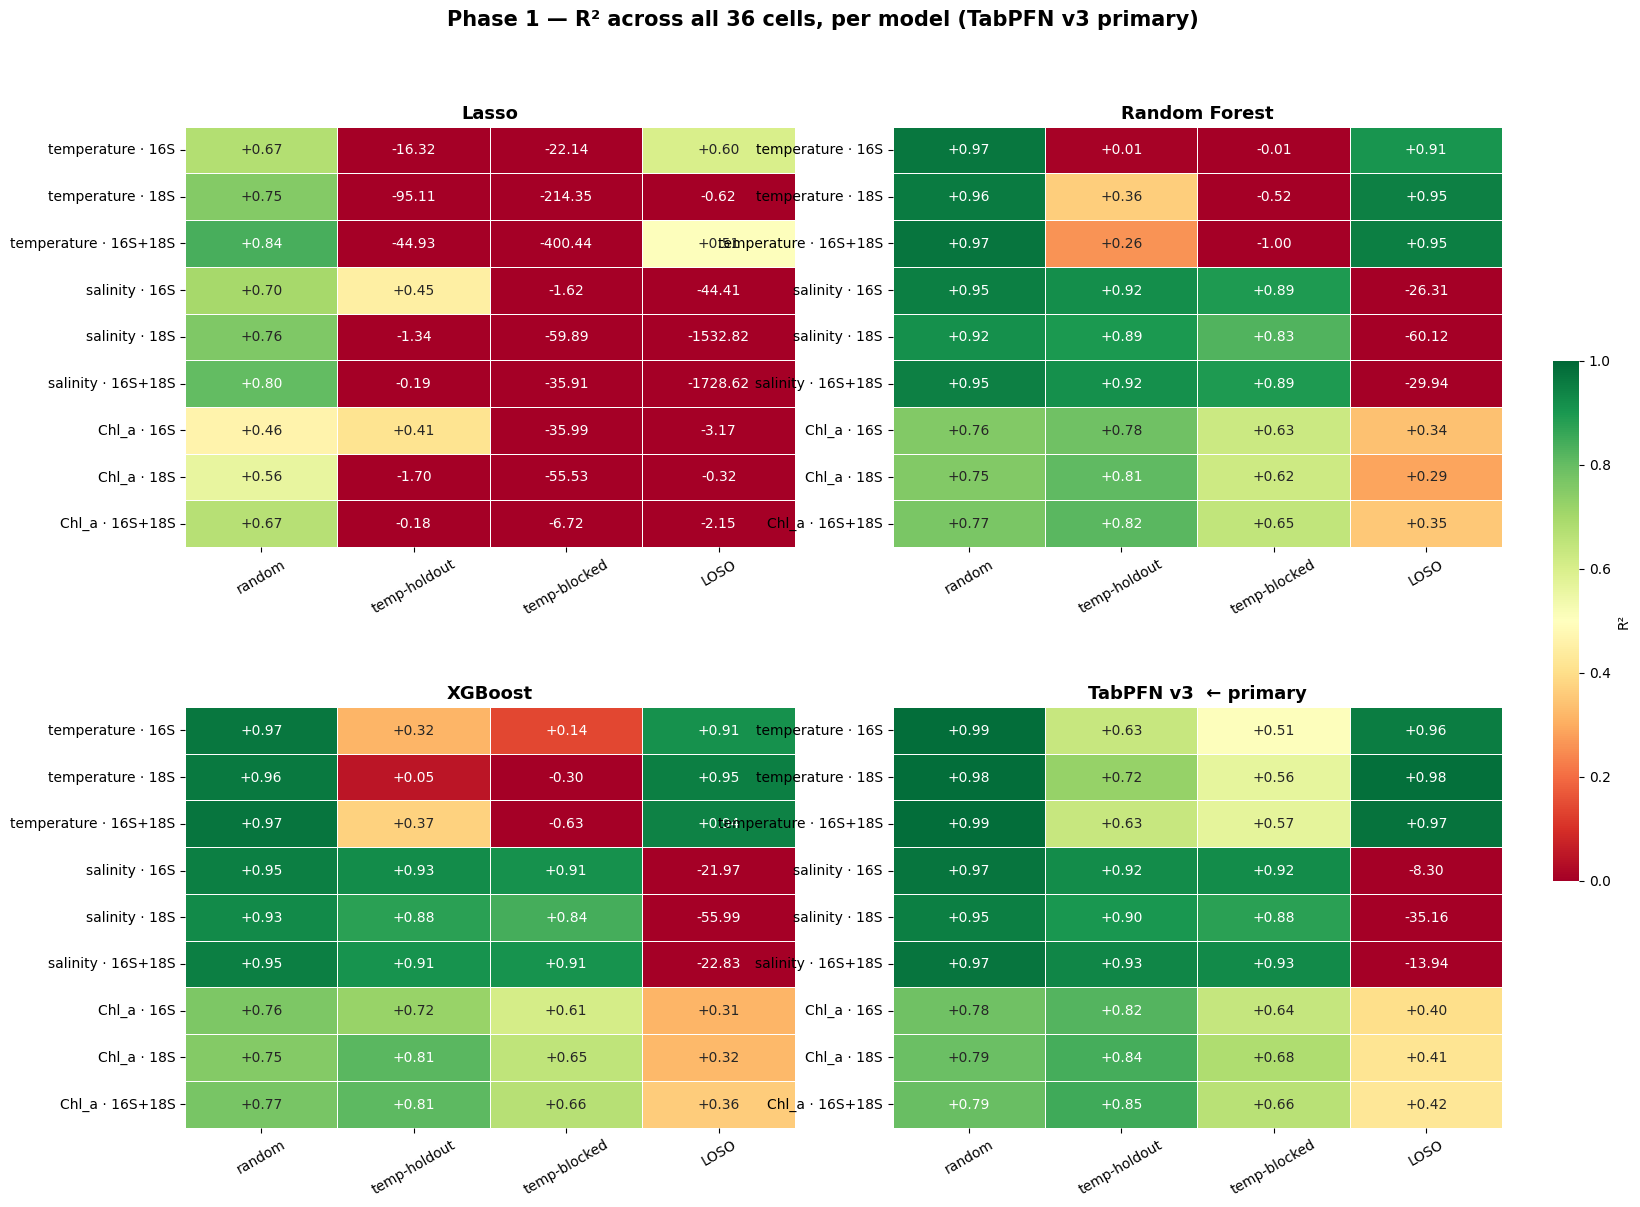

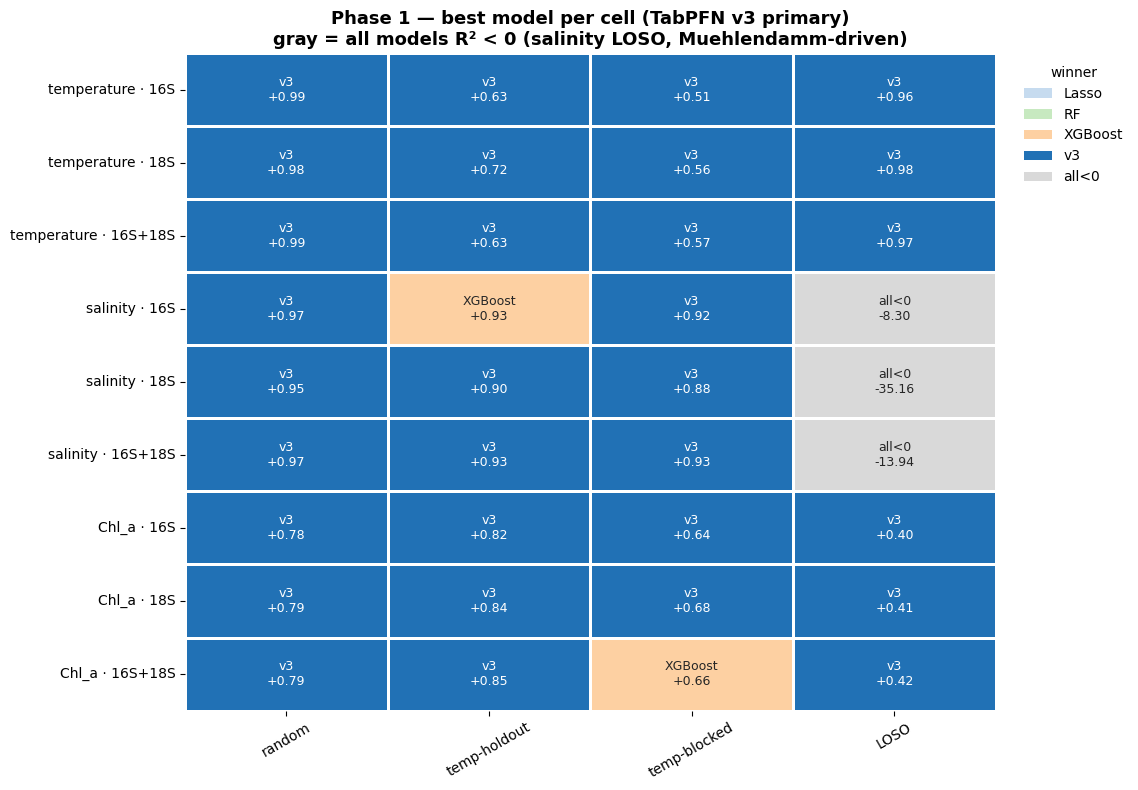

Winner counts across 36 cells:
winner
v3         31
all<0       3
XGBoost     2

Degenerate cells (all models R²<0, salinity LOSO): 3
TabPFN v3 best overall: 31/36
TabPFN v3 best among meaningful (R²≥0) cells: 31/33


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from pathlib import Path

RESULTS_DIR = Path("../results")

target_order   = ['temperature', 'salinity', 'Chl_a_log1p']
input_order    = ['16S', '18S', '16S+18S']
strategy_order = ['random_kfold', 'temporal_holdout', 'temporal_blocked_kfold', 'leave_one_site_out']
strategy_short = {'random_kfold': 'random', 'temporal_holdout': 'temp-holdout',
                  'temporal_blocked_kfold': 'temp-blocked', 'leave_one_site_out': 'LOSO'}
target_disp    = {'temperature': 'temperature', 'salinity': 'salinity', 'Chl_a_log1p': 'Chl_a'}
row_order      = [f"{target_disp[t]} · {i}" for t in target_order for i in input_order]

g = merged.copy()
g['row'] = g['target'].map(target_disp) + ' · ' + g['input'].astype(str)

def pivot(col):
    return (g.pivot(index='row', columns='strategy', values=col)
              .reindex(index=row_order, columns=strategy_order)
              .rename(columns=strategy_short))

# ===================== Figure 1: per-model R² heatmaps (all 36 cells) =====================
models       = ['Lasso', 'RF', 'XGBoost', 'v3']
model_titles = {'Lasso': 'Lasso', 'RF': 'Random Forest', 'XGBoost': 'XGBoost', 'v3': 'TabPFN v3  ← primary'}

fig1, axes = plt.subplots(2, 2, figsize=(17, 13))
fig1.subplots_adjust(right=0.90, hspace=0.38, wspace=0.16)
cbar_ax = fig1.add_axes([0.93, 0.30, 0.015, 0.40])
for ax, mdl in zip(axes.flat, models):
    sns.heatmap(pivot(mdl), annot=True, fmt='+.2f', cmap='RdYlGn', vmin=0.0, vmax=1.0,
                linewidths=0.5, linecolor='white', ax=ax,
                cbar=(mdl == 'v3'), cbar_ax=(cbar_ax if mdl == 'v3' else None),
                cbar_kws={'label': 'R²'})
    ax.set_title(model_titles[mdl], fontweight='bold', fontsize=13)
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=30); ax.tick_params(axis='y', rotation=0)
fig1.suptitle('Phase 1 — R² across all 36 cells, per model (TabPFN v3 primary)',
              fontweight='bold', fontsize=15, y=0.97)
fig1.savefig(RESULTS_DIR / 'phase1_all_models_r2_heatmap.png', dpi=300, bbox_inches='tight')
fig1.savefig(RESULTS_DIR / 'phase1_all_models_r2_heatmap.pdf', bbox_inches='tight')
plt.show()

# ===================== Figure 2: best model per cell (v3 primary) =====================
allm = ['Lasso', 'RF', 'XGBoost', 'v3']
w = merged.copy()
w['best_r2'] = w[allm].max(axis=1)
w['winner']  = w[allm].idxmax(axis=1)
w.loc[w['best_r2'] < 0, 'winner'] = 'all<0'          # degenerate: every model fails
w['row'] = w['target'].map(target_disp) + ' · ' + w['input'].astype(str)

cats   = ['Lasso', 'RF', 'XGBoost', 'v3', 'all<0']
colors = ['#c6dbef', '#c7e9c0', '#fdd0a2', '#2171b5', '#d9d9d9']
code   = {c: i for i, c in enumerate(cats)}

winner_p = w.pivot(index='row', columns='strategy', values='winner').reindex(index=row_order, columns=strategy_order)
bestr2_p = w.pivot(index='row', columns='strategy', values='best_r2').reindex(index=row_order, columns=strategy_order)
code_grid  = winner_p.rename(columns=strategy_short).apply(lambda col: col.map(code))
annot_grid = winner_p.rename(columns=strategy_short).copy()
b = bestr2_p.rename(columns=strategy_short)
for c in annot_grid.columns:
    annot_grid[c] = annot_grid[c].astype(str) + '\n' + b[c].map(lambda v: f"{v:+.2f}")

cmap = ListedColormap(colors)
norm = BoundaryNorm(range(len(cats) + 1), cmap.N)
fig2, ax = plt.subplots(figsize=(11.5, 8))
sns.heatmap(code_grid.astype(float), annot=annot_grid.values, fmt='', cmap=cmap, norm=norm,
            linewidths=1.0, linecolor='white', cbar=False, ax=ax, annot_kws={'fontsize': 9})
ax.set_title('Phase 1 — best model per cell (TabPFN v3 primary)\n'
             'gray = all models R² < 0 (salinity LOSO, Muehlendamm-driven)',
             fontweight='bold', fontsize=13)
ax.set_xlabel(''); ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30); ax.tick_params(axis='y', rotation=0)
ax.legend(handles=[Patch(facecolor=colors[i], label=cats[i]) for i in range(len(cats))],
          bbox_to_anchor=(1.02, 1), loc='upper left', title='winner', frameon=False)
plt.tight_layout()
fig2.savefig(RESULTS_DIR / 'phase1_winner_grid.png', dpi=300, bbox_inches='tight')
fig2.savefig(RESULTS_DIR / 'phase1_winner_grid.pdf', bbox_inches='tight')
plt.show()

# ===================== win-count summary =====================
degen = int((w['best_r2'] < 0).sum())
meaningful = w[w['best_r2'] >= 0]
print("Winner counts across 36 cells:")
print(w['winner'].value_counts().to_string())
print(f"\nDegenerate cells (all models R²<0, salinity LOSO): {degen}")
print(f"TabPFN v3 best overall: {(w['winner']=='v3').sum()}/36")
print(f"TabPFN v3 best among meaningful (R²≥0) cells: {(meaningful['winner']=='v3').sum()}/{len(meaningful)}")

       Target   Input Strategy Lasso    RF XGBoost TabPFN    Best
  temperature     16S   Random  0.68  0.97    0.97   0.98  TabPFN
  temperature     16S  Holdout -16.3  0.01    0.32   0.63  TabPFN
  temperature     16S  Blocked -22.1 -0.01    0.14   0.51  TabPFN
  temperature     16S     LOSO  0.60  0.91    0.91   0.95  TabPFN
  temperature     18S   Random  0.75  0.96    0.96   0.98  TabPFN
  temperature     18S  Holdout -95.1  0.36    0.05   0.72  TabPFN
  temperature     18S  Blocked  -214 -0.52   -0.30   0.56  TabPFN
  temperature     18S     LOSO -0.62  0.95    0.95   0.98  TabPFN
  temperature 16S+18S   Random  0.84  0.97    0.97   0.99  TabPFN
  temperature 16S+18S  Holdout -44.9  0.26    0.37   0.63  TabPFN
  temperature 16S+18S  Blocked  -400 -1.00   -0.63   0.57  TabPFN
  temperature 16S+18S     LOSO  0.51  0.95    0.94   0.97  TabPFN
     salinity     16S   Random  0.70  0.95    0.95   0.97  TabPFN
     salinity     16S  Holdout  0.45  0.92    0.93   0.93 XGBoost
     salin

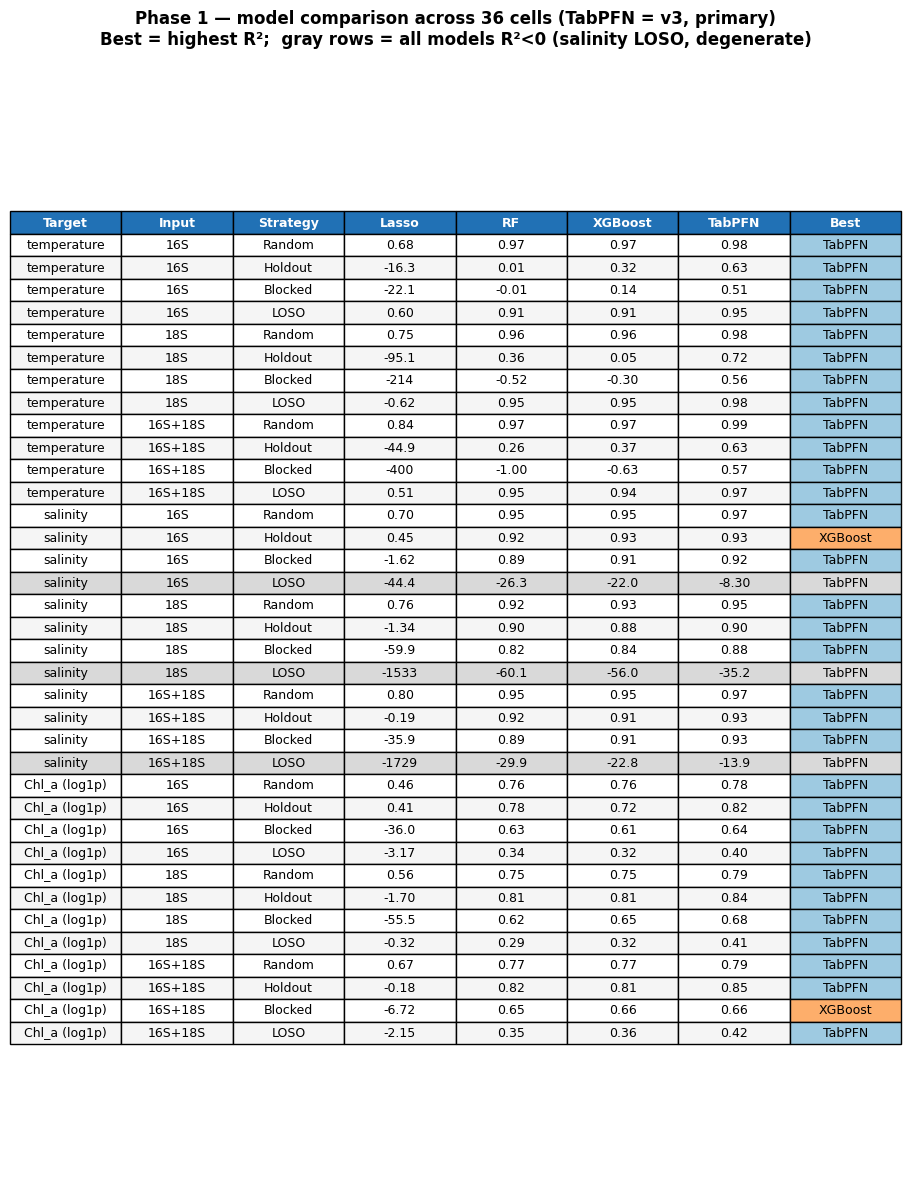

saved → ../results/phase1_final_comparison_table_v3.png


In [17]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

RESULTS_DIR  = Path("../results")
target_order = ['temperature', 'salinity', 'Chl_a_log1p']
input_order  = ['16S', '18S', '16S+18S']
strat_disp = {'random_kfold':'Random', 'temporal_holdout':'Holdout',
              'temporal_blocked_kfold':'Blocked', 'leave_one_site_out':'LOSO'}
targ_disp  = {'temperature':'temperature', 'salinity':'salinity', 'Chl_a_log1p':'Chl_a (log1p)'}

allm = ['Lasso', 'RF', 'XGBoost', 'v3']
tbl = merged.copy()
tbl['Best'] = tbl[allm].idxmax(axis=1).map({'Lasso':'Lasso','RF':'RF','XGBoost':'XGBoost','v3':'TabPFN'})
tbl = tbl.rename(columns={'v3':'TabPFN'})
tbl['Target']   = pd.Categorical(tbl['target'].map(targ_disp), [targ_disp[t] for t in target_order], ordered=True)
tbl['Input']    = pd.Categorical(tbl['input'], input_order, ordered=True)
tbl['Strategy'] = pd.Categorical(tbl['strategy'].map(strat_disp), ['Random','Holdout','Blocked','LOSO'], ordered=True)
tbl = tbl.sort_values(['Target','Input','Strategy']).reset_index(drop=True)

out = tbl[['Target','Input','Strategy','Lasso','RF','XGBoost','TabPFN','Best']].copy()
for c in ['Lasso','RF','XGBoost','TabPFN']:
    out[c] = out[c].round(3)
csv_path = RESULTS_DIR / 'phase1_final_comparison_table_v3.csv'
out.to_csv(csv_path, index=False)

def fmt(v):
    if abs(v) >= 100: return f"{v:.0f}"
    if abs(v) >= 10:  return f"{v:.1f}"
    return f"{v:.2f}"
best_r2   = out[['Lasso','RF','XGBoost','TabPFN']].max(axis=1)
degen_pos = [i for i, v in enumerate((best_r2 < 0).values) if v]
disp = out.copy()
for c in ['Target','Input','Strategy','Best']:
    disp[c] = disp[c].astype(str)
for c in ['Lasso','RF','XGBoost','TabPFN']:
    disp[c] = out[c].map(fmt)

pd.set_option('display.max_rows', 40); pd.set_option('display.width', 150)
print(disp.to_string(index=False))
print(f"\nBest counts: {out['Best'].value_counts().to_dict()}")
print(f"saved → {csv_path}")

# ---------- rendered table image (Best highlighted, degenerate rows flagged) ----------
fig, ax = plt.subplots(figsize=(11.5, 14.5)); ax.axis('off')
cols = list(disp.columns)
t = ax.table(cellText=disp.values, colLabels=cols, cellLoc='center', loc='center')
t.auto_set_font_size(False); t.set_fontsize(9); t.scale(1, 1.35)
best_fill = {'TabPFN':'#9ecae1', 'XGBoost':'#fdae6b', 'RF':'#a1d99b', 'Lasso':'#cccccc'}
for j in range(len(cols)):
    h = t[(0, j)]; h.set_facecolor('#2171b5'); h.set_text_props(color='white', fontweight='bold')
for i in range(len(disp)):
    base = '#f5f5f5' if i % 2 else '#ffffff'
    for j in range(len(cols)):
        t[(i+1, j)].set_facecolor(base)
    t[(i+1, cols.index('Best'))].set_facecolor(best_fill.get(out['Best'].iloc[i], '#ffffff'))
for p in degen_pos:
    for j in range(len(cols)):
        t[(p+1, j)].set_facecolor('#d9d9d9')
ax.set_title('Phase 1 — model comparison across 36 cells (TabPFN = v3, primary)\n'
             'Best = highest R²;  gray rows = all models R²<0 (salinity LOSO, degenerate)',
             fontweight='bold', fontsize=12, pad=18)
img_path = RESULTS_DIR / 'phase1_final_comparison_table_v3.png'
fig.savefig(img_path, dpi=300, bbox_inches='tight')
fig.savefig(RESULTS_DIR / 'phase1_final_comparison_table_v3.pdf', bbox_inches='tight')
plt.show()
print(f"saved → {img_path}")

       Target   Input Strategy Lasso    RF XGBoost TabPFN              Best
  temperature     16S   Random  0.68  0.97    0.97   0.98            TabPFN
  temperature     16S  Holdout -16.3  0.01    0.32   0.63            TabPFN
  temperature     16S  Blocked -22.1 -0.01    0.14   0.51            TabPFN
  temperature     16S     LOSO  0.60  0.91    0.91   0.95            TabPFN
  temperature     18S   Random  0.75  0.96    0.96   0.98            TabPFN
  temperature     18S  Holdout -95.1  0.36    0.05   0.72            TabPFN
  temperature     18S  Blocked  -214 -0.52   -0.30   0.56            TabPFN
  temperature     18S     LOSO -0.62  0.95    0.95   0.98            TabPFN
  temperature 16S+18S   Random  0.84  0.97    0.97   0.99            TabPFN
  temperature 16S+18S  Holdout -44.9  0.26    0.37   0.63            TabPFN
  temperature 16S+18S  Blocked  -400 -1.00   -0.63   0.57            TabPFN
  temperature 16S+18S     LOSO  0.51  0.95    0.94   0.97            TabPFN
     salinit

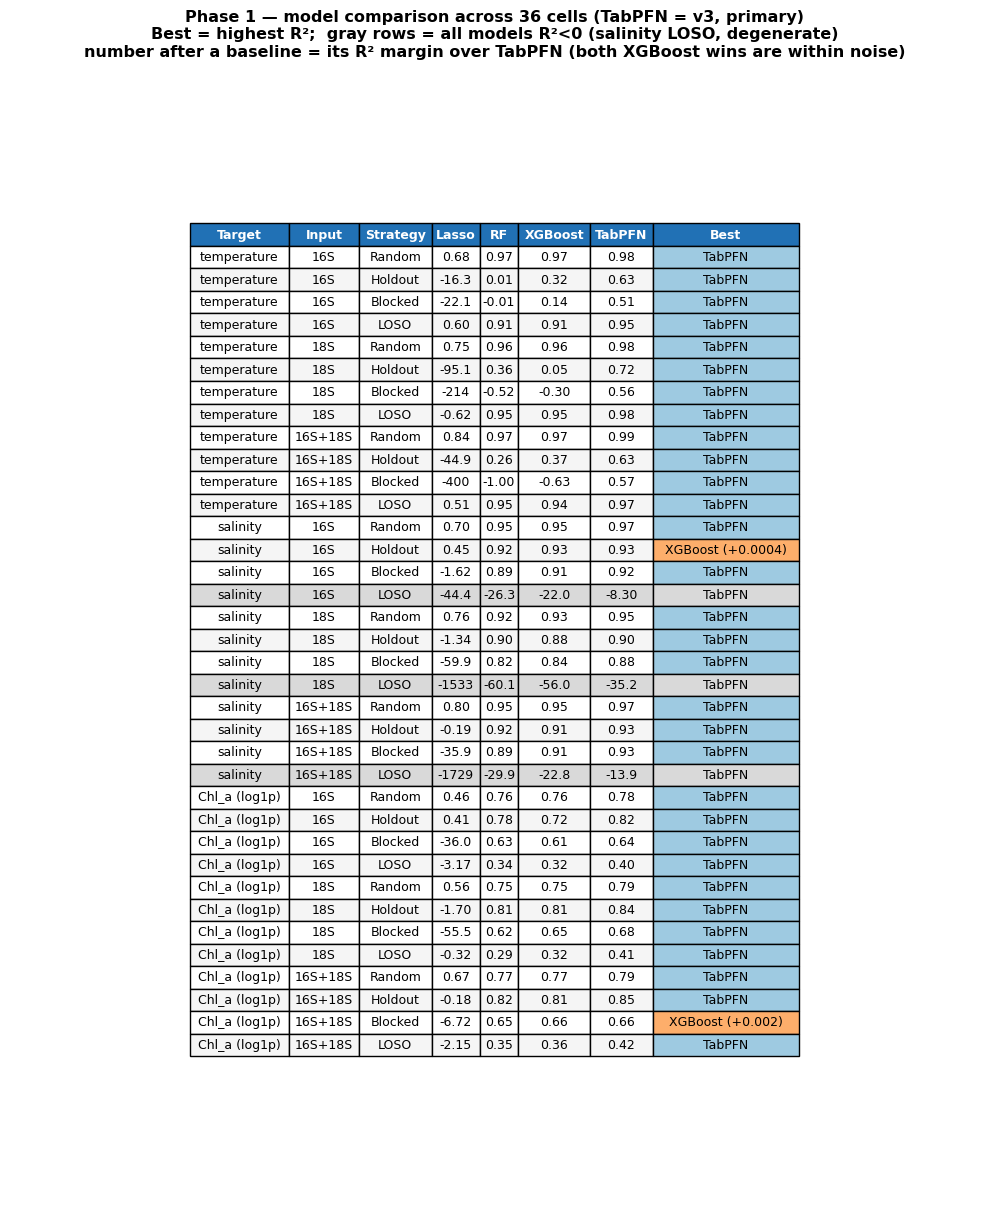

saved → ../results/phase1_final_comparison_table_v3.png


In [18]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

RESULTS_DIR  = Path("../results")
target_order = ['temperature', 'salinity', 'Chl_a_log1p']
input_order  = ['16S', '18S', '16S+18S']
strat_disp = {'random_kfold':'Random', 'temporal_holdout':'Holdout',
              'temporal_blocked_kfold':'Blocked', 'leave_one_site_out':'LOSO'}
targ_disp  = {'temperature':'temperature', 'salinity':'salinity', 'Chl_a_log1p':'Chl_a (log1p)'}

allm = ['Lasso', 'RF', 'XGBoost', 'v3']
tbl = merged.copy()
tbl['Best'] = tbl[allm].idxmax(axis=1).map({'Lasso':'Lasso','RF':'RF','XGBoost':'XGBoost','v3':'TabPFN'})
tbl = tbl.rename(columns={'v3':'TabPFN'})
tbl['Target']   = pd.Categorical(tbl['target'].map(targ_disp), [targ_disp[t] for t in target_order], ordered=True)
tbl['Input']    = pd.Categorical(tbl['input'], input_order, ordered=True)
tbl['Strategy'] = pd.Categorical(tbl['strategy'].map(strat_disp), ['Random','Holdout','Blocked','LOSO'], ordered=True)
tbl = tbl.sort_values(['Target','Input','Strategy']).reset_index(drop=True)

out = tbl[['Target','Input','Strategy','Lasso','RF','XGBoost','TabPFN','Best']].copy()
for c in ['Lasso','RF','XGBoost','TabPFN']:
    out[c] = out[c].round(3)
csv_path = RESULTS_DIR / 'phase1_final_comparison_table_v3.csv'
out.to_csv(csv_path, index=False)

def fmt(v):
    if abs(v) >= 100: return f"{v:.0f}"
    if abs(v) >= 10:  return f"{v:.1f}"
    return f"{v:.2f}"
def margin_fmt(m):
    return f"+{m:.4f}" if abs(m) < 0.001 else f"+{m:.3f}"

# Best-cell text: append the baseline's R² margin over TabPFN where a baseline wins
best_text = []
for i in range(len(tbl)):
    b = tbl['Best'].iloc[i]
    if b == 'TabPFN':
        best_text.append('TabPFN')
    else:
        m = tbl[b].iloc[i] - tbl['TabPFN'].iloc[i]
        best_text.append(f"{b} ({margin_fmt(m)})")

best_r2   = out[['Lasso','RF','XGBoost','TabPFN']].max(axis=1)
degen_pos = [i for i, v in enumerate((best_r2 < 0).values) if v]
disp = out.copy()
for c in ['Target','Input','Strategy']:
    disp[c] = disp[c].astype(str)
for c in ['Lasso','RF','XGBoost','TabPFN']:
    disp[c] = out[c].map(fmt)
disp['Best'] = best_text

pd.set_option('display.max_rows', 40); pd.set_option('display.width', 160)
print(disp.to_string(index=False))
print(f"\nBest counts: {out['Best'].value_counts().to_dict()}")
print(f"saved → {csv_path}")

# ---------- rendered table image ----------
fig, ax = plt.subplots(figsize=(12.5, 14.5)); ax.axis('off')
cols = list(disp.columns)
t = ax.table(cellText=disp.values, colLabels=cols, cellLoc='center', loc='center')
t.auto_set_font_size(False); t.set_fontsize(9)
t.auto_set_column_width(col=list(range(len(cols))))
t.scale(1, 1.35)
best_fill = {'TabPFN':'#9ecae1', 'XGBoost':'#fdae6b', 'RF':'#a1d99b', 'Lasso':'#cccccc'}
for j in range(len(cols)):
    h = t[(0, j)]; h.set_facecolor('#2171b5'); h.set_text_props(color='white', fontweight='bold')
for i in range(len(disp)):
    base = '#f5f5f5' if i % 2 else '#ffffff'
    for j in range(len(cols)):
        t[(i+1, j)].set_facecolor(base)
    t[(i+1, cols.index('Best'))].set_facecolor(best_fill.get(out['Best'].iloc[i], '#ffffff'))
for p in degen_pos:
    for j in range(len(cols)):
        t[(p+1, j)].set_facecolor('#d9d9d9')
ax.set_title('Phase 1 — model comparison across 36 cells (TabPFN = v3, primary)\n'
             'Best = highest R²;  gray rows = all models R²<0 (salinity LOSO, degenerate)\n'
             'number after a baseline = its R² margin over TabPFN (both XGBoost wins are within noise)',
             fontweight='bold', fontsize=11.5, pad=18)
img_path = RESULTS_DIR / 'phase1_final_comparison_table_v3.png'
fig.savefig(img_path, dpi=300, bbox_inches='tight')
fig.savefig(RESULTS_DIR / 'phase1_final_comparison_table_v3.pdf', bbox_inches='tight')
plt.show()
print(f"saved → {img_path}")

In [19]:
import pandas as pd
from pathlib import Path
RES = Path("../results")
KEYS = ['target','input','strategy']
TNORM = {'Chl_a (log1p)':'Chl_a_log1p'}

# 1) freshly read the canonical per-model CSVs that `merged` uses
src = {'Lasso':'phase1_lasso_3targets_3inputs_4strategies.csv',
       'RF':'phase1_random_forest_3targets_3inputs_4strategies.csv',
       'XGBoost':'phase1_xgboost_3targets_3inputs_4strategies.csv',
       'v3':'phase1_tabpfn_v3_3targets_3inputs_4strategies.csv'}
raw = {}
for label, f in src.items():
    d = pd.read_csv(RES/f)[KEYS+['r2_mean']].copy()
    d['target'] = d['target'].replace(TNORM)
    raw[label] = d.set_index(KEYS)['r2_mean']

mi = merged.set_index(KEYS)
print("1) merged  vs  freshly-read canonical CSVs (should be ~0):")
for label in src:
    diff = (mi[label]-raw[label]).abs()
    print(f"   {label:8s}: max|Δ| = {diff.max():.2e}")

# 2) current RF/XGBoost/Lasso CSVs  vs  the OLD four_model_comparison
fmc = pd.read_csv(RES/'phase1_four_model_comparison.csv').rename(columns={'target_display':'target'})
fmc['target'] = fmc['target'].replace(TNORM)
fmc_i = fmc.set_index(KEYS)
print("\n2) current per-model CSV  vs  phase1_four_model_comparison.csv:")
for label in ['Lasso','RF','XGBoost']:
    common = raw[label].index.intersection(fmc_i.index)
    diff = (raw[label].loc[common]-fmc_i[label].loc[common]).abs()
    big = diff[diff>0.01].sort_values(ascending=False)
    print(f"   {label:8s}: max|Δ|={diff.max():.3f}   cells differing >0.01: {len(big)}")
    for key, dv in big.head(6).items():
        print(f"        {key[0]:12s} {key[1]:8s} {key[2]:22s}  current={raw[label].loc[key]:+.3f}  four_model={fmc_i[label].loc[key]:+.3f}")

# 3) exact current values (4 dp) for every cell
ot=['temperature','salinity','Chl_a_log1p']; oi=['16S','18S','16S+18S']
os_=['random_kfold','temporal_holdout','temporal_blocked_kfold','leave_one_site_out']
full = merged.copy()
full['target']=pd.Categorical(full['target'],ot,ordered=True)
full['input']=pd.Categorical(full['input'],oi,ordered=True)
full['strategy']=pd.Categorical(full['strategy'],os_,ordered=True)
full=full.sort_values(['target','input','strategy'])
pd.set_option('display.max_rows',40); pd.set_option('display.width',170)
print("\n3) exact current values (4 dp) from merged:")
print(full[['target','input','strategy','Lasso','RF','XGBoost','v2.6','v3']].round(4).to_string(index=False))

1) merged  vs  freshly-read canonical CSVs (should be ~0):
   Lasso   : max|Δ| = 0.00e+00
   RF      : max|Δ| = 0.00e+00
   XGBoost : max|Δ| = 0.00e+00
   v3      : max|Δ| = 0.00e+00

2) current per-model CSV  vs  phase1_four_model_comparison.csv:
   Lasso   : max|Δ|=0.001   cells differing >0.01: 0
   RF      : max|Δ|=0.001   cells differing >0.01: 0
   XGBoost : max|Δ|=0.001   cells differing >0.01: 0

3) exact current values (4 dp) from merged:
     target   input               strategy      Lasso       RF  XGBoost     v2.6       v3
temperature     16S           random_kfold     0.6746   0.9662   0.9687   0.9833   0.9852
temperature     16S       temporal_holdout   -16.3173   0.0076   0.3160   0.5732   0.6336
temperature     16S temporal_blocked_kfold   -22.1450  -0.0069   0.1375   0.4545   0.5054
temperature     16S     leave_one_site_out     0.6005   0.9060   0.9135   0.9477   0.9552
temperature     18S           random_kfold     0.7500   0.9584   0.9637   0.9831   0.9850
temperat

       Target   Input Strategy  Lasso     RF XGBoost TabPFN              Best
  temperature     16S   Random  0.675  0.966   0.969  0.985            TabPFN
  temperature     16S  Holdout  -16.3  0.008   0.316  0.634            TabPFN
  temperature     16S  Blocked  -22.1 -0.007   0.138  0.505            TabPFN
  temperature     16S     LOSO  0.601  0.906   0.913  0.955            TabPFN
  temperature     18S   Random  0.750  0.958   0.964  0.985            TabPFN
  temperature     18S  Holdout  -95.1  0.364   0.046  0.723            TabPFN
  temperature     18S  Blocked   -214 -0.524  -0.299  0.563            TabPFN
  temperature     18S     LOSO -0.622  0.949   0.952  0.981            TabPFN
  temperature 16S+18S   Random  0.837  0.971   0.973  0.986            TabPFN
  temperature 16S+18S  Holdout  -44.9  0.262   0.372  0.634            TabPFN
  temperature 16S+18S  Blocked   -400 -0.997  -0.626  0.570            TabPFN
  temperature 16S+18S     LOSO  0.507  0.950   0.942  0.974     

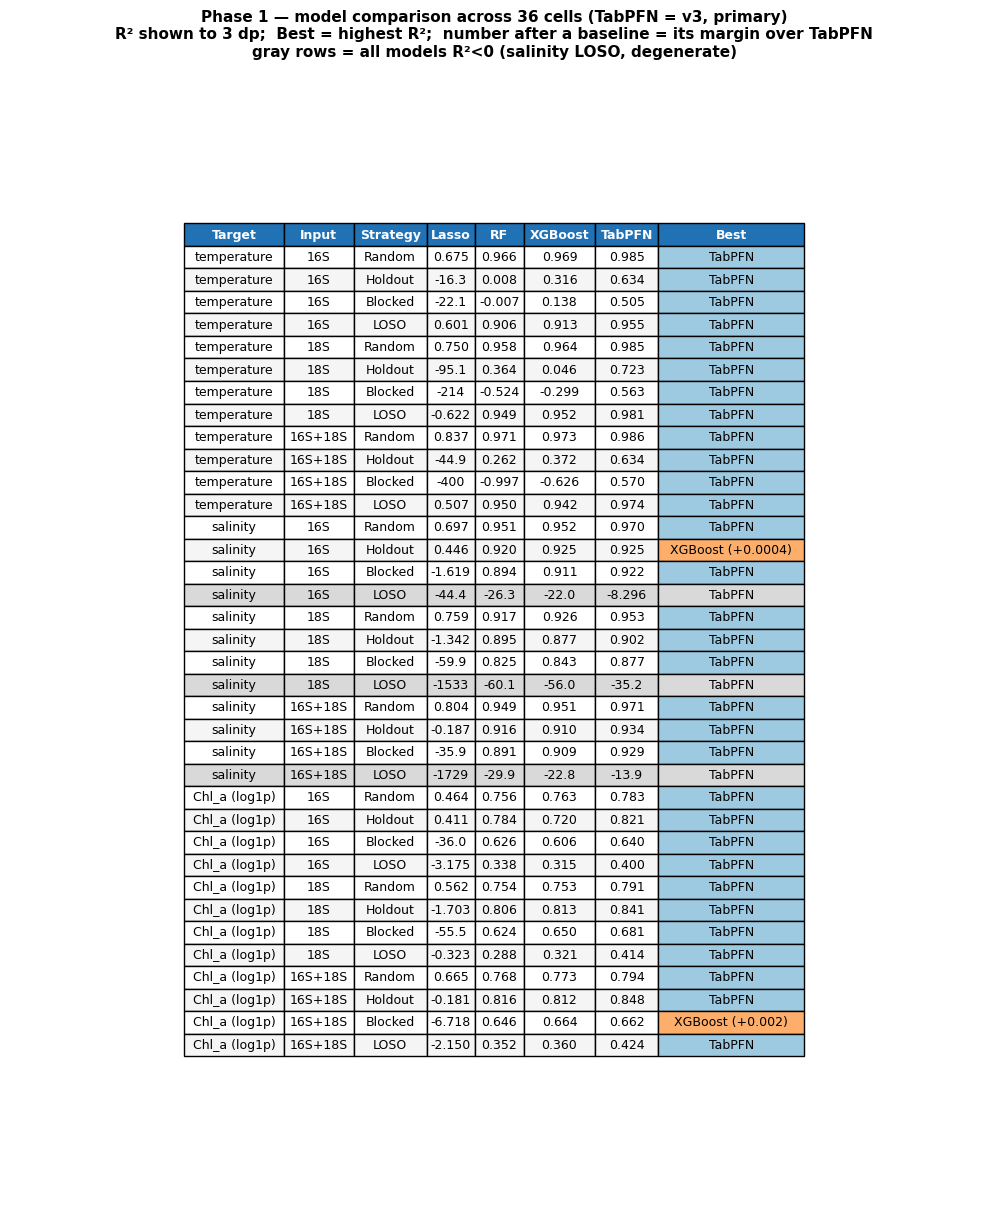

saved → ../results/phase1_final_comparison_table_v3.png


In [20]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

RESULTS_DIR  = Path("../results")
target_order = ['temperature', 'salinity', 'Chl_a_log1p']
input_order  = ['16S', '18S', '16S+18S']
strat_disp = {'random_kfold':'Random', 'temporal_holdout':'Holdout',
              'temporal_blocked_kfold':'Blocked', 'leave_one_site_out':'LOSO'}
targ_disp  = {'temperature':'temperature', 'salinity':'salinity', 'Chl_a_log1p':'Chl_a (log1p)'}

allm = ['Lasso', 'RF', 'XGBoost', 'v3']
tbl = merged.copy()
tbl['Best'] = tbl[allm].idxmax(axis=1).map({'Lasso':'Lasso','RF':'RF','XGBoost':'XGBoost','v3':'TabPFN'})
tbl = tbl.rename(columns={'v3':'TabPFN'})
tbl['Target']   = pd.Categorical(tbl['target'].map(targ_disp), [targ_disp[t] for t in target_order], ordered=True)
tbl['Input']    = pd.Categorical(tbl['input'], input_order, ordered=True)
tbl['Strategy'] = pd.Categorical(tbl['strategy'].map(strat_disp), ['Random','Holdout','Blocked','LOSO'], ordered=True)
tbl = tbl.sort_values(['Target','Input','Strategy']).reset_index(drop=True)

out = tbl[['Target','Input','Strategy','Lasso','RF','XGBoost','TabPFN','Best']].copy()
for c in ['Lasso','RF','XGBoost','TabPFN']:
    out[c] = out[c].round(4)
csv_path = RESULTS_DIR / 'phase1_final_comparison_table_v3.csv'
out.to_csv(csv_path, index=False)

def fmt(v):                       # 3 decimals in the 0–10 range so near-ties aren't distorted
    if abs(v) >= 100: return f"{v:.0f}"
    if abs(v) >= 10:  return f"{v:.1f}"
    return f"{v:.3f}"
def margin_fmt(m):
    return f"+{m:.4f}" if abs(m) < 0.001 else f"+{m:.3f}"

best_text = []
for i in range(len(tbl)):
    bcol = tbl['Best'].iloc[i]
    if bcol == 'TabPFN':
        best_text.append('TabPFN')
    else:
        m = tbl[bcol].iloc[i] - tbl['TabPFN'].iloc[i]     # full-precision margin over TabPFN
        best_text.append(f"{bcol} ({margin_fmt(m)})")

best_r2   = tbl[['Lasso','RF','XGBoost','TabPFN']].max(axis=1)
degen_pos = [i for i, v in enumerate((best_r2 < 0).values) if v]
disp = tbl[['Target','Input','Strategy']].astype(str).copy()
for c in ['Lasso','RF','XGBoost','TabPFN']:
    disp[c] = tbl[c].map(fmt)         # format from FULL precision — no double-rounding
disp['Best'] = best_text

pd.set_option('display.max_rows',40); pd.set_option('display.width',160)
print(disp.to_string(index=False))
print(f"\nBest counts: {tbl['Best'].value_counts().to_dict()}")
print(f"saved → {csv_path}")

fig, ax = plt.subplots(figsize=(12.5, 14.5)); ax.axis('off')
cols = list(disp.columns)
t = ax.table(cellText=disp.values, colLabels=cols, cellLoc='center', loc='center')
t.auto_set_font_size(False); t.set_fontsize(9)
t.auto_set_column_width(col=list(range(len(cols))))
t.scale(1, 1.35)
best_fill = {'TabPFN':'#9ecae1', 'XGBoost':'#fdae6b', 'RF':'#a1d99b', 'Lasso':'#cccccc'}
for j in range(len(cols)):
    h = t[(0, j)]; h.set_facecolor('#2171b5'); h.set_text_props(color='white', fontweight='bold')
for i in range(len(disp)):
    base = '#f5f5f5' if i % 2 else '#ffffff'
    for j in range(len(cols)):
        t[(i+1, j)].set_facecolor(base)
    t[(i+1, cols.index('Best'))].set_facecolor(best_fill.get(tbl['Best'].iloc[i], '#ffffff'))
for p in degen_pos:
    for j in range(len(cols)):
        t[(p+1, j)].set_facecolor('#d9d9d9')
ax.set_title('Phase 1 — model comparison across 36 cells (TabPFN = v3, primary)\n'
             'R² shown to 3 dp;  Best = highest R²;  number after a baseline = its margin over TabPFN\n'
             'gray rows = all models R²<0 (salinity LOSO, degenerate)',
             fontweight='bold', fontsize=11, pad=18)
img_path = RESULTS_DIR / 'phase1_final_comparison_table_v3.png'
fig.savefig(img_path, dpi=300, bbox_inches='tight')
fig.savefig(RESULTS_DIR / 'phase1_final_comparison_table_v3.pdf', bbox_inches='tight')
plt.show()
print(f"saved → {img_path}")

In [7]:
# for new start its not important when i run every cell from the top 

import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("../results")
KEYS  = ['target','input','strategy']
TNORM = {'Chl_a (log1p)':'Chl_a_log1p'}   # Lasso labels chlorophyll differently

files = {
    'Lasso':   'phase1_lasso_3targets_3inputs_4strategies.csv',
    'RF':      'phase1_random_forest_3targets_3inputs_4strategies.csv',
    'XGBoost': 'phase1_xgboost_3targets_3inputs_4strategies.csv',
    'v2.6':    'phase1_tabpfn_v26_3targets_3inputs_4strategies.csv',
    'v3':      'phase1_tabpfn_v3_3targets_3inputs_4strategies.csv',
}

merged = None
for label, fname in files.items():
    d = pd.read_csv(RESULTS_DIR / fname)[KEYS + ['r2_mean']].copy()
    d['target'] = d['target'].replace(TNORM)
    d = d.rename(columns={'r2_mean': label})
    merged = d if merged is None else merged.merge(d, on=KEYS, how='outer')

print(f"merged rebuilt: {len(merged)} cells (should be 36) · "
      f"missing: {merged[list(files)].isna().any(axis=1).sum()}")

merged rebuilt: 36 cells (should be 36) · missing: 0


       Target   Input Strategy      Lasso       RF  XGBoost   TabPFN              Best
  temperature     16S   Random     0.6746   0.9662   0.9687   0.9852            TabPFN
  temperature     16S  Holdout   -16.3173   0.0076   0.3160   0.6336            TabPFN
  temperature     16S  Blocked   -22.1450  -0.0069   0.1375   0.5054            TabPFN
  temperature     16S     LOSO     0.6005   0.9060   0.9135   0.9552            TabPFN
  temperature     18S   Random     0.7500   0.9584   0.9637   0.9850            TabPFN
  temperature     18S  Holdout   -95.1117   0.3638   0.0458   0.7227            TabPFN
  temperature     18S  Blocked  -214.3508  -0.5240  -0.2990   0.5629            TabPFN
  temperature     18S     LOSO    -0.6217   0.9492   0.9516   0.9807            TabPFN
  temperature 16S+18S   Random     0.8368   0.9707   0.9725   0.9863            TabPFN
  temperature 16S+18S  Holdout   -44.9346   0.2615   0.3719   0.6345            TabPFN
  temperature 16S+18S  Blocked  -400.4392  

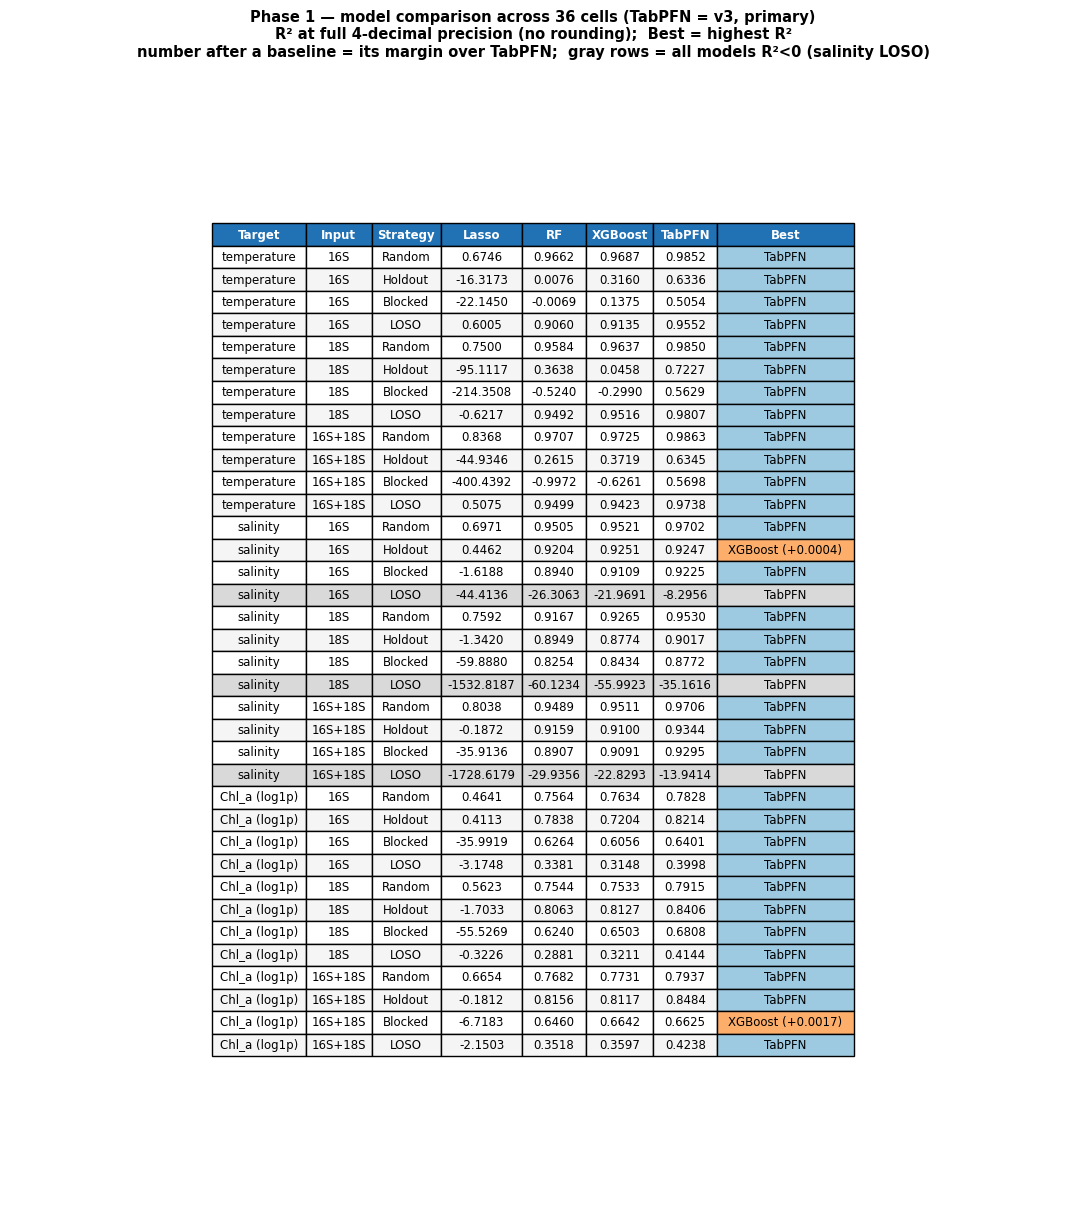

saved → ../results/phase1_final_comparison_table_v3.png


In [8]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

RESULTS_DIR  = Path("../results")
target_order = ['temperature', 'salinity', 'Chl_a_log1p']
input_order  = ['16S', '18S', '16S+18S']
strat_disp = {'random_kfold':'Random', 'temporal_holdout':'Holdout',
              'temporal_blocked_kfold':'Blocked', 'leave_one_site_out':'LOSO'}
targ_disp  = {'temperature':'temperature', 'salinity':'salinity', 'Chl_a_log1p':'Chl_a (log1p)'}

allm = ['Lasso', 'RF', 'XGBoost', 'v3']
tbl = merged.copy()
tbl['Best'] = tbl[allm].idxmax(axis=1).map({'Lasso':'Lasso','RF':'RF','XGBoost':'XGBoost','v3':'TabPFN'})
tbl = tbl.rename(columns={'v3':'TabPFN'})
tbl['Target']   = pd.Categorical(tbl['target'].map(targ_disp), [targ_disp[t] for t in target_order], ordered=True)
tbl['Input']    = pd.Categorical(tbl['input'], input_order, ordered=True)
tbl['Strategy'] = pd.Categorical(tbl['strategy'].map(strat_disp), ['Random','Holdout','Blocked','LOSO'], ordered=True)
tbl = tbl.sort_values(['Target','Input','Strategy']).reset_index(drop=True)

out = tbl[['Target','Input','Strategy','Lasso','RF','XGBoost','TabPFN','Best']].copy()
for c in ['Lasso','RF','XGBoost','TabPFN']:
    out[c] = out[c].round(4)
csv_path = RESULTS_DIR / 'phase1_final_comparison_table_v3.csv'
out.to_csv(csv_path, index=False)

def fmt(v):            # full 4-decimal precision — no rounding ambiguity anywhere
    return f"{v:.4f}"
def margin_fmt(m):
    return f"+{m:.4f}"

best_text = []
for i in range(len(tbl)):
    bcol = tbl['Best'].iloc[i]
    if bcol == 'TabPFN':
        best_text.append('TabPFN')
    else:
        m = tbl[bcol].iloc[i] - tbl['TabPFN'].iloc[i]
        best_text.append(f"{bcol} ({margin_fmt(m)})")

best_r2   = tbl[['Lasso','RF','XGBoost','TabPFN']].max(axis=1)
degen_pos = [i for i, v in enumerate((best_r2 < 0).values) if v]
disp = tbl[['Target','Input','Strategy']].astype(str).copy()
for c in ['Lasso','RF','XGBoost','TabPFN']:
    disp[c] = tbl[c].map(fmt)
disp['Best'] = best_text

pd.set_option('display.max_rows',40); pd.set_option('display.width',200)
print(disp.to_string(index=False))
print(f"\nBest counts: {tbl['Best'].value_counts().to_dict()}")
print(f"saved → {csv_path}")

fig, ax = plt.subplots(figsize=(13.5, 14.5)); ax.axis('off')
cols = list(disp.columns)
t = ax.table(cellText=disp.values, colLabels=cols, cellLoc='center', loc='center')
t.auto_set_font_size(False); t.set_fontsize(8.5)
t.auto_set_column_width(col=list(range(len(cols))))
t.scale(1, 1.35)
best_fill = {'TabPFN':'#9ecae1', 'XGBoost':'#fdae6b', 'RF':'#a1d99b', 'Lasso':'#cccccc'}
for j in range(len(cols)):
    h = t[(0, j)]; h.set_facecolor('#2171b5'); h.set_text_props(color='white', fontweight='bold')
for i in range(len(disp)):
    base = '#f5f5f5' if i % 2 else '#ffffff'
    for j in range(len(cols)):
        t[(i+1, j)].set_facecolor(base)
    t[(i+1, cols.index('Best'))].set_facecolor(best_fill.get(tbl['Best'].iloc[i], '#ffffff'))
for p in degen_pos:
    for j in range(len(cols)):
        t[(p+1, j)].set_facecolor('#d9d9d9')
ax.set_title('Phase 1 — model comparison across 36 cells (TabPFN = v3, primary)\n'
             'R² at full 4-decimal precision (no rounding);  Best = highest R²\n'
             'number after a baseline = its margin over TabPFN;  gray rows = all models R²<0 (salinity LOSO)',
             fontweight='bold', fontsize=10.5, pad=18)
img_path = RESULTS_DIR / 'phase1_final_comparison_table_v3.png'
fig.savefig(img_path, dpi=300, bbox_inches='tight')
fig.savefig(RESULTS_DIR / 'phase1_final_comparison_table_v3.pdf', bbox_inches='tight')
plt.show()
print(f"saved → {img_path}")

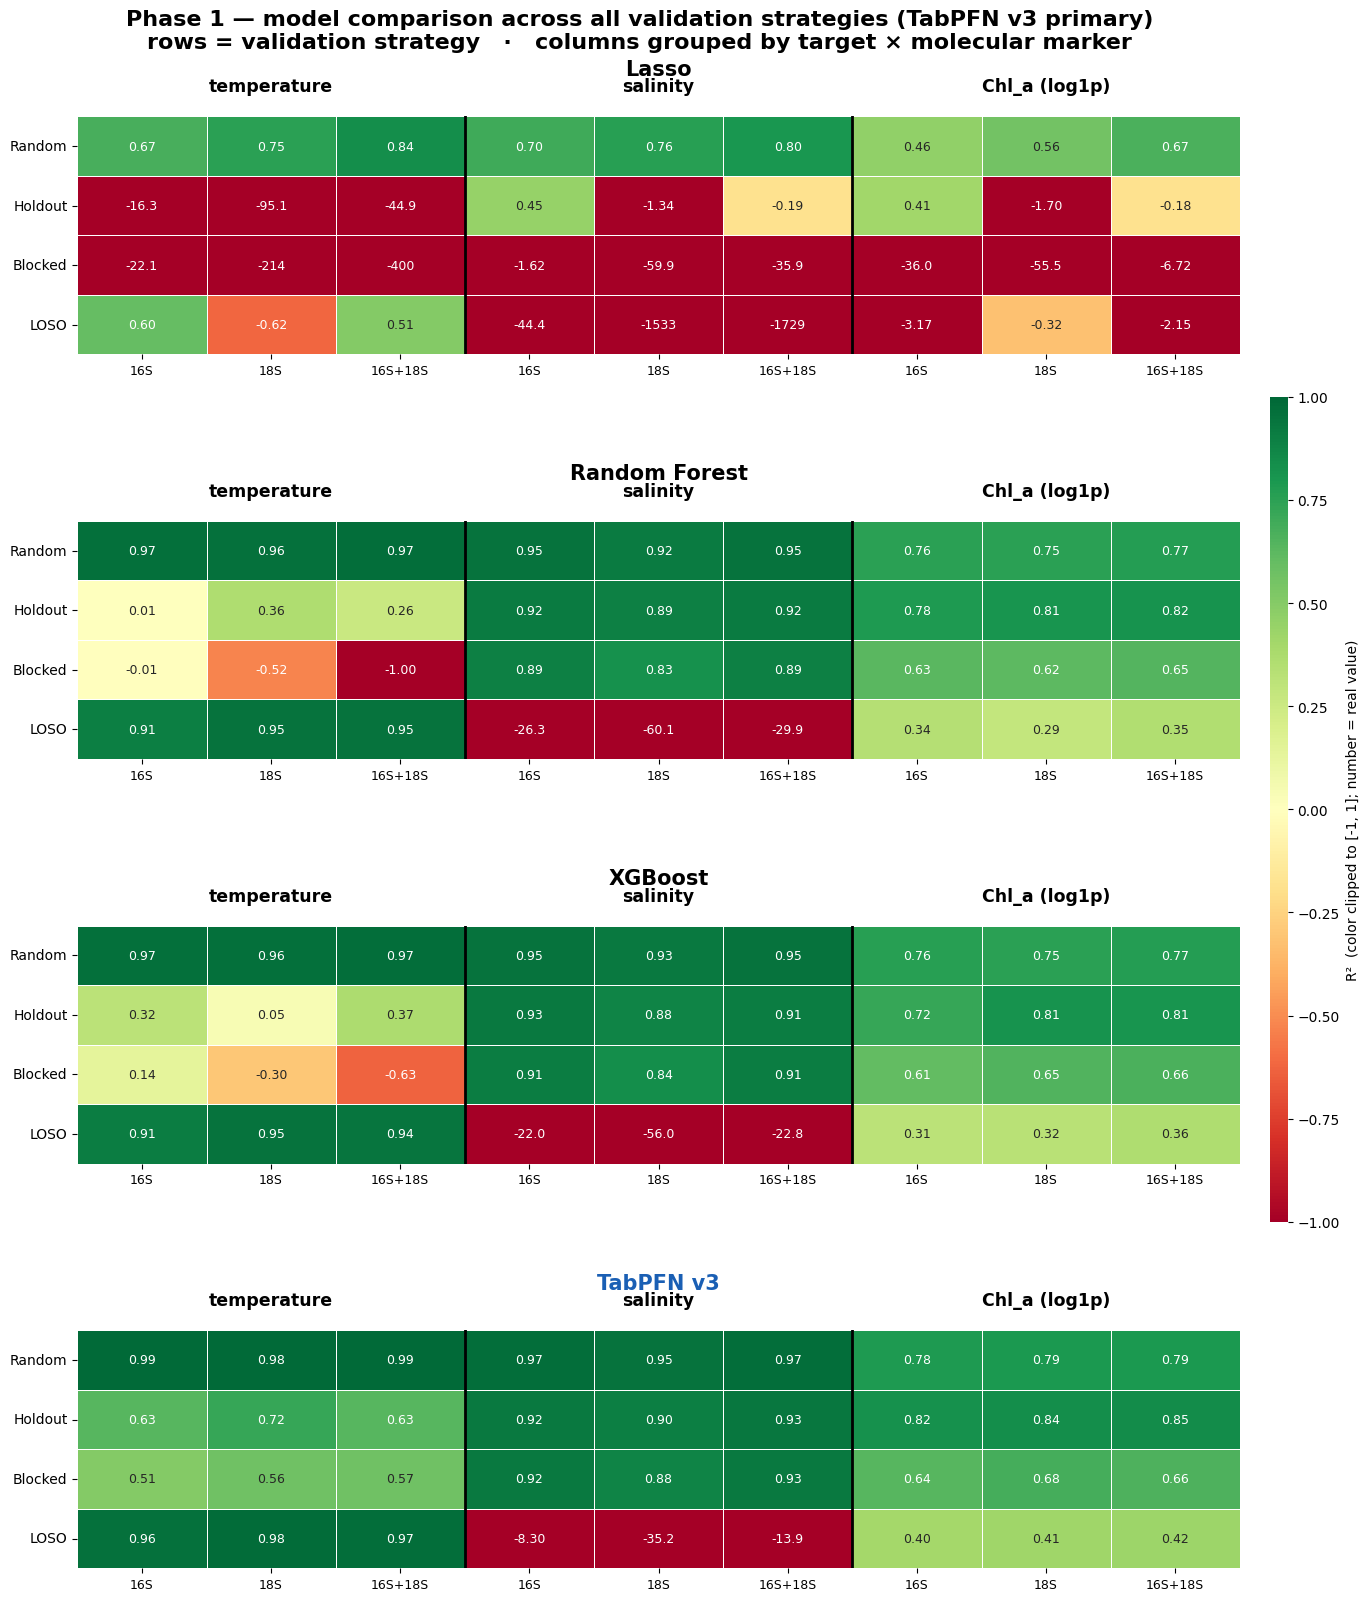

saved → ../results/phase1_heatmap_presentation_v3.png


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

RESULTS_DIR = Path("../results")
t_order = ['temperature', 'salinity', 'Chl_a_log1p']
t_disp  = {'temperature':'temperature', 'salinity':'salinity', 'Chl_a_log1p':'Chl_a (log1p)'}
i_order = ['16S', '18S', '16S+18S']
s_order = ['random_kfold', 'temporal_holdout', 'temporal_blocked_kfold', 'leave_one_site_out']
s_disp  = ['Random', 'Holdout', 'Blocked', 'LOSO']
col_tuples = [(t, i) for t in t_order for i in i_order]
models = [('Lasso','Lasso'), ('RF','Random Forest'), ('XGBoost','XGBoost'), ('v3','TabPFN v3')]

idx = merged.set_index(['strategy','target','input'])
def matrix(model):
    s = idx[model]
    return np.array([[s.loc[(st, t, i)] for (t, i) in col_tuples] for st in s_order])
def afmt(v):
    if abs(v) >= 100: return f"{v:.0f}"
    if abs(v) >= 10:  return f"{v:.1f}"
    return f"{v:.2f}"

fig, axes = plt.subplots(len(models), 1, figsize=(15, 16.5))
fig.subplots_adjust(right=0.9, hspace=0.7, top=0.92, bottom=0.04)
cbar_ax = fig.add_axes([0.92, 0.25, 0.012, 0.5])

for k, (ax, (mkey, mtitle)) in enumerate(zip(axes, models)):
    M = matrix(mkey)
    annot = np.vectorize(afmt)(M)
    sns.heatmap(M, ax=ax, cmap='RdYlGn', vmin=-1, vmax=1, center=0,
                annot=annot, fmt='', annot_kws={'fontsize':9},
                linewidths=0.5, linecolor='white',
                xticklabels=[i for (_, i) in col_tuples], yticklabels=s_disp,
                cbar=(k == 0), cbar_ax=(cbar_ax if k == 0 else None),
                cbar_kws={'label': 'R²  (color clipped to [-1, 1]; number = real value)'})
    ax.set_title(mtitle, fontweight='bold', fontsize=15, pad=30,
                 color=('#1a5fb4' if mkey == 'v3' else 'black'))
    ax.tick_params(axis='y', rotation=0, labelsize=10)
    ax.tick_params(axis='x', rotation=0, labelsize=9)
    ax.set_xlabel(''); ax.set_ylabel('')
    for x in (3, 6):
        ax.axvline(x, color='black', lw=2)
    for g, t in enumerate(t_order):
        ax.text(g*3 + 1.5, -0.35, t_disp[t], ha='center', va='bottom',
                fontsize=12.5, fontweight='bold', clip_on=False)

fig.suptitle('Phase 1 — model comparison across all validation strategies (TabPFN v3 primary)\n'
             'rows = validation strategy   ·   columns grouped by target × molecular marker',
             fontweight='bold', fontsize=16, y=0.985)

png = RESULTS_DIR / 'phase1_heatmap_presentation_v3.png'
fig.savefig(png, dpi=300, bbox_inches='tight')
fig.savefig(RESULTS_DIR / 'phase1_heatmap_presentation_v3.pdf', bbox_inches='tight')
plt.show()
print(f"saved → {png}")

In [1]:
import pandas as pd, glob
for f in sorted(glob.glob('../results/*.csv')):
    try:
        cols = list(pd.read_csv(f, nrows=0).columns)
    except Exception as e:
        cols = f'<error: {e}>'
    print(f.split('/')[-1], '->', cols)

loso_salinity_per_site_rf.csv -> ['fold', 'site_id', 'n_test', 'salinity_mean', 'salinity_std', 'site_name', 'r2_16S', 'r2_18S', 'r2_16S+18S', 'r2_worst']
phase1_baselines_3targets_16s.csv -> ['model', 'target', 'transform', 'n_samples', 'r2_mean', 'r2_std', 'mae_mean', 'mae_std', 'rmse_mean', 'rmse_std']
phase1_comparison_lasso_vs_xgboost.csv -> ['strategy', 'input', 'target', 'n_folds', 'n_samples', 'n_features', 'r2_mean', 'r2_std', 'mae_mean', 'mae_std', 'rmse_mean', 'rmse_std', 'alpha_mean', 'n_selected_mean', 'total_time', 'model', 'target_display', 'log_target', 'best_max_depth_mode', 'best_lr_mode', 'best_n_est_mode']
phase1_final_comparison_table_v3.csv -> ['Target', 'Input', 'Strategy', 'Lasso', 'RF', 'XGBoost', 'TabPFN', 'Best']
phase1_four_model_comparison.csv -> ['target_display', 'input', 'strategy', 'Lasso', 'RF', 'XGBoost', 'TabPFN', 'best_model', 'best_r2']
phase1_lasso_3newstrategies.csv -> ['strategy', 'input', 'target', 'n_folds', 'n_samples', 'n_features', 'r2_mean

In [2]:
import pandas as pd
df = pd.read_csv('../results/phase1_final_comparison_table_v3.csv')
print('shape:', df.shape)
print('Targets :', list(df['Target'].unique()))
print('Inputs  :', list(df['Input'].unique()))
print('Strategy:', list(df['Strategy'].unique()))

models = ['Lasso', 'RF', 'XGBoost', 'TabPFN']
df[models] = df[models].apply(pd.to_numeric, errors='coerce')
df['winner'] = df[models].idxmax(axis=1)
df['tabpfn_margin'] = df['TabPFN'] - df[['Lasso', 'RF', 'XGBoost']].max(axis=1)  # vs best baseline

non_wins = df[df['winner'] != 'TabPFN']
print(f'\nTabPFN best in {len(df) - len(non_wins)}/{len(df)} cells; NOT best in {len(non_wins)}:')
cols = ['Target', 'Input', 'Strategy', 'Lasso', 'RF', 'XGBoost', 'TabPFN', 'winner', 'tabpfn_margin']
print(non_wins[cols].to_string(index=False))

shape: (36, 8)
Targets : ['temperature', 'salinity', 'Chl_a (log1p)']
Inputs  : ['16S', '18S', '16S+18S']
Strategy: ['Random', 'Holdout', 'Blocked', 'LOSO']

TabPFN best in 34/36 cells; NOT best in 2:
       Target   Input Strategy   Lasso     RF  XGBoost  TabPFN  winner  tabpfn_margin
     salinity     16S  Holdout  0.4462 0.9204   0.9251  0.9247 XGBoost        -0.0004
Chl_a (log1p) 16S+18S  Blocked -6.7183 0.6460   0.6642  0.6625 XGBoost        -0.0017


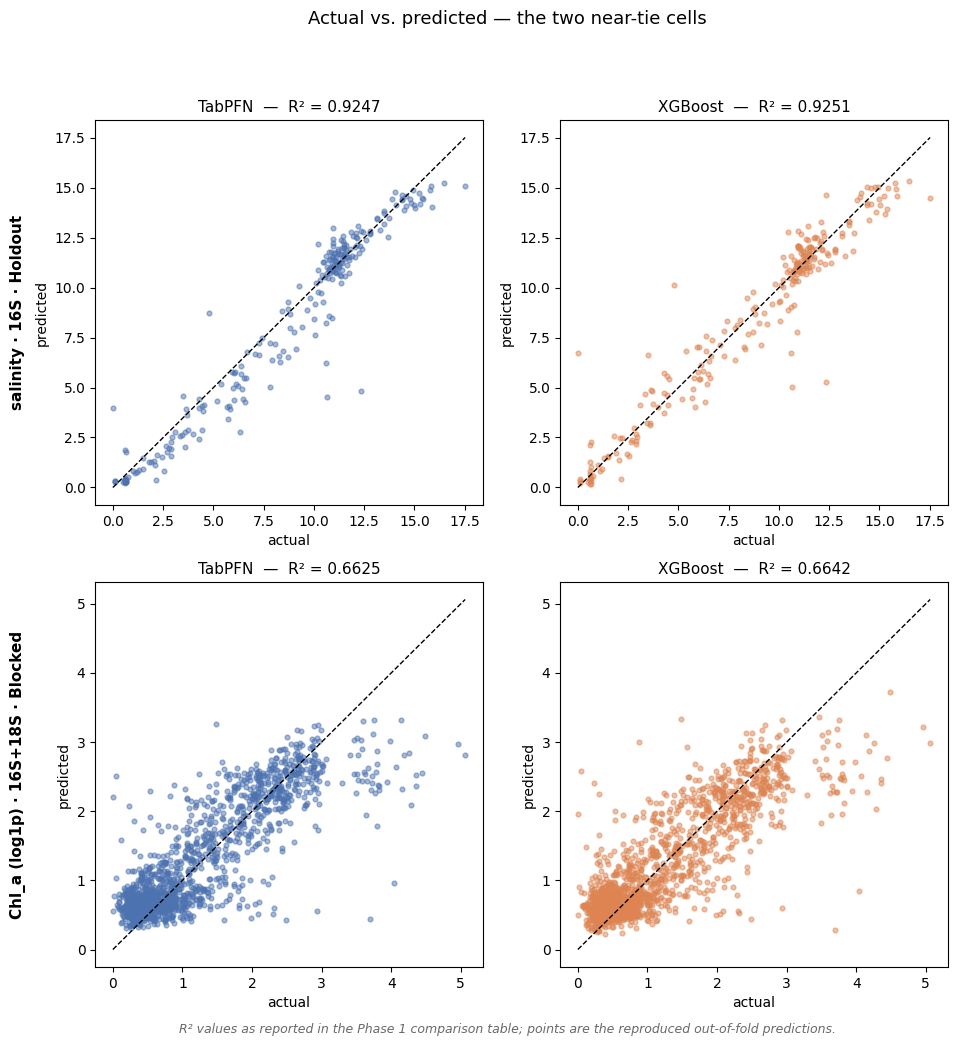

saved -> ../results/phase1_tie_cells_actual_vs_pred.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 11))
for r, c in enumerate(cells):
    tbl = {'TabPFN': c['table_tab'], 'XGBoost': c['table_xgb']}
    for col, name in enumerate(['TabPFN', 'XGBoost']):
        ax = axes[r, col]; d = results[c['label']][name]
        ax.scatter(d['yt'], d['yp'], s=12, alpha=0.5, color='#4C72B0' if name == 'TabPFN' else '#DD8452')
        lo, hi = min(d['yt'].min(), d['yp'].min()), max(d['yt'].max(), d['yp'].max())
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
        ax.set_title(f"{name}  —  R² = {tbl[name]:.4f}", fontsize=11)
        ax.set_xlabel('actual'); ax.set_ylabel('predicted')
    axes[r, 0].annotate(c['label'], xy=(-0.22, 0.5), xycoords='axes fraction',
                        rotation=90, va='center', fontsize=11, fontweight='bold')
fig.suptitle('Actual vs. predicted — the two near-tie cells', fontsize=13)
fig.text(0.5, 0.05,
         'R² values as reported in the Phase 1 comparison table; points are the reproduced out-of-fold predictions.',
         ha='center', fontsize=9, style='italic', color='dimgray')
out = Path('..') / 'results' / 'phase1_tie_cells_actual_vs_pred.png'
fig.savefig(out, dpi=300, bbox_inches='tight'); plt.show(); print('saved ->', out)

In [1]:
import pandas as pd
from pathlib import Path

RESULTS = Path("../results")

# load all models
lasso = pd.read_csv(RESULTS / 'phase1_lasso_3targets_3inputs_4strategies.csv')
rf    = pd.read_csv(RESULTS / 'phase1_random_forest_3targets_3inputs_4strategies.csv')
xgb   = pd.read_csv(RESULTS / 'phase1_xgboost_3targets_3inputs_4strategies.csv')
tab   = pd.read_csv(RESULTS / 'phase1_tabpfn_v3_3targets_3inputs_4strategies.csv')

# add model column
for df, name in [(lasso, 'Lasso'), (rf, 'RF'), (xgb, 'XGBoost'), (tab, 'TabPFN')]:
    df['model'] = name

# concat
all_models = pd.concat([lasso, rf, xgb, tab], ignore_index=True)

# focused view: target × input × strategy × model → all 3 metrics
summary = all_models[['model', 'target', 'input', 'strategy', 
                       'r2_mean', 'mae_mean', 'rmse_mean']].copy()
summary = summary.round({'r2_mean': 3, 'mae_mean': 3, 'rmse_mean': 3})

# save to a single appendix-ready file
summary.to_csv(RESULTS / 'phase1_full_metrics_appendix.csv', index=False)

print(f"Saved {len(summary)} rows ({len(summary)//4} cells × 4 models)")
print(summary.head(10).to_string(index=False))

Saved 144 rows (36 cells × 4 models)
model      target   input               strategy  r2_mean  mae_mean  rmse_mean
Lasso temperature     16S           random_kfold    0.675     2.578        NaN
Lasso temperature     16S       temporal_holdout  -16.317     5.807      9.473
Lasso temperature     16S temporal_blocked_kfold  -22.145     7.372     12.228
Lasso temperature     16S     leave_one_site_out    0.600     2.768      3.866
Lasso temperature     18S           random_kfold    0.750     1.913        NaN
Lasso temperature     18S       temporal_holdout  -95.112    10.773     22.316
Lasso temperature     18S temporal_blocked_kfold -214.351    13.183     32.558
Lasso temperature     18S     leave_one_site_out   -0.622     2.671      5.457
Lasso temperature 16S+18S           random_kfold    0.837     1.705        NaN
Lasso temperature 16S+18S       temporal_holdout  -44.935     7.835     15.428


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

RESULTS = Path("../results")

# ─── Load all 4 models ──────────────────────────────────────────────
lasso = pd.read_csv(RESULTS / 'phase1_lasso_3targets_3inputs_4strategies.csv')
rf    = pd.read_csv(RESULTS / 'phase1_random_forest_3targets_3inputs_4strategies.csv')
xgb   = pd.read_csv(RESULTS / 'phase1_xgboost_3targets_3inputs_4strategies.csv')
tab   = pd.read_csv(RESULTS / 'phase1_tabpfn_v3_3targets_3inputs_4strategies.csv')

# Add model column
for df, name in [(lasso, 'Lasso'), (rf, 'RF'), (xgb, 'XGBoost'), (tab, 'TabPFN')]:
    df['model'] = name

# Normalize target names (Lasso had 'Chl_a (log1p)' while others had 'Chl_a_log1p')
def normalize_target(t):
    t = str(t).strip()
    if 'Chl_a' in t:
        return 'Chl_a_log1p'
    return t

for df in [lasso, rf, xgb, tab]:
    df['target'] = df['target'].apply(normalize_target)

# Concat
all_models = pd.concat([lasso, rf, xgb, tab], ignore_index=True)

print(f"Loaded {len(all_models)} rows total ({len(all_models)//4} cells × 4 models)")
print(f"Targets: {sorted(all_models['target'].unique())}")
print(f"Inputs:  {sorted(all_models['input'].unique())}")
print(f"Strategies: {sorted(all_models['strategy'].unique())}")

Loaded 144 rows total (36 cells × 4 models)
Targets: ['Chl_a_log1p', 'salinity', 'temperature']
Inputs:  ['16S', '16S+18S', '18S']
Strategies: ['leave_one_site_out', 'random_kfold', 'temporal_blocked_kfold', 'temporal_holdout']


In [3]:
# ─── Pivot: برای هر سل، یک ردیف با ۴ مدل ───────────────────────
def build_metric_pivot(metric_col):
    """Pivot: rows=cells, columns=models, values=metric"""
    return all_models.pivot_table(
        index=['target', 'input', 'strategy'],
        columns='model',
        values=metric_col,
    ).reset_index()

# Build for all 3 metrics
r2_pivot   = build_metric_pivot('r2_mean')
mae_pivot  = build_metric_pivot('mae_mean')
rmse_pivot = build_metric_pivot('rmse_mean')

# ─── برای هر متریک، چک کن TabPFN برنده‌ست یا نه ─────────────────
# نکته مهم: برای R² برنده = بالاترین، برای MAE/RMSE برنده = کمترین

def check_winner(pivot, metric_name, higher_is_better):
    """Check in how many cells TabPFN is the best."""
    models = ['Lasso', 'RF', 'XGBoost', 'TabPFN']
    pivot = pivot.copy()
    
    if higher_is_better:
        pivot['winner'] = pivot[models].idxmax(axis=1)
        pivot['tabpfn_value'] = pivot['TabPFN']
        pivot['best_baseline'] = pivot[['Lasso', 'RF', 'XGBoost']].max(axis=1)
        pivot['margin'] = pivot['TabPFN'] - pivot['best_baseline']
    else:
        pivot['winner'] = pivot[models].idxmin(axis=1)
        pivot['tabpfn_value'] = pivot['TabPFN']
        pivot['best_baseline'] = pivot[['Lasso', 'RF', 'XGBoost']].min(axis=1)
        pivot['margin'] = pivot['best_baseline'] - pivot['TabPFN']  # positive = TabPFN wins
    
    tabpfn_wins = (pivot['winner'] == 'TabPFN').sum()
    total = len(pivot)
    
    print(f"\n{'='*70}")
    print(f"  {metric_name} — TabPFN wins: {tabpfn_wins} / {total} cells")
    print(f"{'='*70}")
    print(f"  Mean margin (TabPFN better by): {pivot['margin'].mean():+.4f}")
    print(f"  Median margin:                  {pivot['margin'].median():+.4f}")
    
    # Show losing cells in detail
    losses = pivot[pivot['winner'] != 'TabPFN']
    if len(losses) > 0:
        print(f"\n  Cells where TabPFN is NOT the winner ({len(losses)}):")
        cols = ['target', 'input', 'strategy', 'winner', 'TabPFN', 'best_baseline', 'margin']
        print(losses[cols].round(4).to_string(index=False))
    else:
        print(f"\n  ✓ TabPFN wins all {total} cells!")
    
    return tabpfn_wins, total

# Run all 3
r2_wins,   r2_total   = check_winner(r2_pivot,   'R² (higher is better)',   higher_is_better=True)
mae_wins,  mae_total  = check_winner(mae_pivot,  'MAE (lower is better)',   higher_is_better=False)
rmse_wins, rmse_total = check_winner(rmse_pivot, 'RMSE (lower is better)',  higher_is_better=False)

# ─── Cross-metric agreement ──────────────────────────────────────
print(f"\n{'='*70}")
print(f"  CROSS-METRIC AGREEMENT")
print(f"{'='*70}")
print(f"  R²:   {r2_wins}/{r2_total}")
print(f"  MAE:  {mae_wins}/{mae_total}")
print(f"  RMSE: {rmse_wins}/{rmse_total}")


  R² (higher is better) — TabPFN wins: 34 / 36 cells
  Mean margin (TabPFN better by): +1.3193
  Median margin:                  +0.0298

  Cells where TabPFN is NOT the winner (2):
     target   input               strategy  winner  TabPFN  best_baseline  margin
Chl_a_log1p 16S+18S temporal_blocked_kfold XGBoost  0.6625         0.6642 -0.0017
   salinity     16S       temporal_holdout XGBoost  0.9247         0.9251 -0.0004

  MAE (lower is better) — TabPFN wins: 35 / 36 cells
  Mean margin (TabPFN better by): +0.2514
  Median margin:                  +0.2085

  Cells where TabPFN is NOT the winner (1):
  target input         strategy  winner  TabPFN  best_baseline  margin
salinity   16S temporal_holdout XGBoost   0.783          0.758  -0.025

  RMSE (lower is better) — TabPFN wins: 35 / 36 cells
  Mean margin (TabPFN better by): +0.2975
  Median margin:                  +0.2260

  Cells where TabPFN is NOT the winner (1):
  target input         strategy  winner  TabPFN  best_baseline

In [1]:
# ── CELL 15: verify effective sample sizes per target (env + chemical) ──────
import pandas as pd
from pathlib import Path

PROJ = Path('/mnt/data/home/tv2414/tabpfn_project')
RESULTS = PROJ / 'results'

print('=== (a) n_samples recorded per cell in the Phase 1 result files ===')
for label, f in [('TabPFN v3', 'phase1_tabpfn_v3_3targets_3inputs_4strategies.csv'),
                 ('RF', 'phase1_random_forest_3targets_3inputs_4strategies.csv')]:
    d = pd.read_csv(RESULTS / f)
    print(f'\n{label}:')
    print(d.groupby('target')['n_samples'].agg(['min', 'max', 'nunique']).to_string())

print('\n=== (b) directly from meta_clean.csv ===')
meta = pd.read_csv(PROJ / 'data/processed/meta_clean.csv', index_col=0)
for col in ['temperature', 'salinity', 'Chl_a_log1p']:
    print(f'  {col:14s} non-missing = {meta[col].notna().sum()}')
print(f'  total rows = {len(meta)} · stations = {meta["location_name"].nunique()}')

print('\n=== (c) chemical targets: n per compound (Phase 3 files) ===')
for f in ['phase3_tabpfn_3targets_3inputs_4strategies.csv',
          'phase3_fourmodel_comparison_16S.csv']:
    p = RESULTS / f
    if p.exists():
        d = pd.read_csv(p)
        print(f'\n{f}  columns: {list(d.columns)}')
        ncol = next((c for c in d.columns if 'n_sample' in c or c == 'n'), None)
        tcol = next((c for c in d.columns if 'target' in c), None)
        if ncol and tcol:
            print(d.groupby(tcol)[ncol].agg(['min', 'max']).to_string())

=== (a) n_samples recorded per cell in the Phase 1 result files ===

TabPFN v3:
              min   max  nunique
target                          
Chl_a_log1p  1437  1437        1
salinity     1217  1217        1
temperature  1223  1223        1

RF:
              min   max  nunique
target                          
Chl_a_log1p  1437  1437        1
salinity     1217  1217        1
temperature  1223  1223        1

=== (b) directly from meta_clean.csv ===
  temperature    non-missing = 1223
  salinity       non-missing = 1217
  Chl_a_log1p    non-missing = 1437
  total rows = 1538 · stations = 14

=== (c) chemical targets: n per compound (Phase 3 files) ===

phase3_tabpfn_3targets_3inputs_4strategies.csv  columns: ['model', 'target_display', 'target', 'input', 'strategy', 'r2_mean', 'r2_std', 'mae_mean', 'mae_std', 'rmse_mean', 'rmse_std', 'n_samples', 'n_features', 'n_folds', 'total_time']
                 min   max
target_display            
Atrazine        1289  1289
Caffeine        12